In [1]:
import pandas as pd

file_path = '/content/rideBookings_preprocessed1.xlsx'
df = pd.read_excel(file_path)
print(df.head())

        Date      Time  Booking ID       Booking Status Customer ID  \
0 2024-01-01  18:05:08  CNR2589191            Completed  CID8552101   
1 2024-01-01  18:39:09  CNR6304210            Completed  CID7004065   
2 2024-01-01  17:26:26  CNR4423001  Cancelled by Driver  CID6188095   
3 2024-01-01  20:22:33  CNR7294075            Completed  CID6392882   
4 2024-01-01  05:52:06  CNR2972763  Cancelled by Driver  CID4100766   

  Vehicle Type Pickup Location       Drop Location  Avg VTAT  Avg CTAT  ...  \
0         Auto    Jahangirpuri               Saket       3.8      20.1  ...   
1      Uber XL     IGI Airport        Udyog Bhawan       7.5      33.2  ...   
2         Bike      IGNOU Road  Bhikaji Cama Place       7.8       NaN  ...   
3         Bike     Qutub Minar      Kanhaiya Nagar      11.7      18.1  ...   
4     Go Sedan     DLF Phase 3     Noida Sector 62       3.4       NaN  ...   

   Customer Rating Payment Method            Datetime  Year  Month Day  \
0              4.5    Ub

In [2]:
import warnings, textwrap
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#3a3d4a",
    "axes.labelcolor":  "#e0e0e0",
    "text.color":       "#e0e0e0",
    "xtick.color":      "#b0b0b0",
    "ytick.color":      "#b0b0b0",
    "grid.color":       "#2e3140",
    "grid.linestyle":   "--",
    "grid.linewidth":   0.5,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   12,
    "axes.labelsize":   10,
    "legend.framealpha": 0.3,
    "legend.facecolor": "#1a1d27",
    "legend.edgecolor": "#3a3d4a",
})

PALETTE = ["#7c83fd","#f9c74f","#90be6d","#f94144","#43aa8b","#f8961e","#577590","#a8dadc"]
ACCENT, ACCENT2, SUCCESS, DANGER = "#7c83fd", "#f9c74f", "#90be6d", "#f94144"

def style_ax(ax, title="", xlabel="", ylabel="", grid="y"):
    ax.set_title(title, fontsize=12, fontweight="bold", color="#ffffff", pad=10)
    ax.set_xlabel(xlabel, labelpad=6)
    ax.set_ylabel(ylabel, labelpad=6)
    ax.spines[["top","right"]].set_visible(False)
    if grid == "y":    ax.yaxis.grid(True, alpha=0.3)
    elif grid == "x":  ax.xaxis.grid(True, alpha=0.3)
    elif grid == "both": ax.yaxis.grid(True, alpha=0.3); ax.xaxis.grid(True, alpha=0.3)
    return ax

In [3]:
df = pd.read_excel("rideBookings_preprocessed1.xlsx")
df["Datetime"]  = pd.to_datetime(df["Datetime"])
df["DayName"]   = df["DayOfWeek"].map({0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"})
df["MonthName"] = df["Month"].map({1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
                                    7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"})
print(f"Shape      : {df.shape}")
print(f"Date range : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"\nDtypes:\n{df.dtypes.to_string()}")

Shape      : (148767, 31)
Date range : 2024-01-01 → 2024-12-30

Dtypes:
Date                                 datetime64[ns]
Time                                         object
Booking ID                                   object
Booking Status                               object
Customer ID                                  object
Vehicle Type                                 object
Pickup Location                              object
Drop Location                                object
Avg VTAT                                    float64
Avg CTAT                                    float64
Cancelled Rides by Customer                 float64
Reason for cancelling by Customer            object
Cancelled Rides by Driver                   float64
Driver Cancellation Reason                   object
Incomplete Rides                            float64
Incomplete Rides Reason                      object
Booking Value                               float64
Ride Distance                               

In [4]:
display(df.head())

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
display(pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct}).query("`Missing Count` > 0"))

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Datetime,Year,Month,Day,DayOfWeek,Hour,WeekOfYear,IsWeekend,DayName,MonthName
0,2024-01-01,18:05:08,CNR2589191,Completed,CID8552101,Auto,Jahangirpuri,Saket,3.8,20.1,...,2024-01-01 18:05:08,2024,1,1,0,18,1,0,Mon,Jan
1,2024-01-01,18:39:09,CNR6304210,Completed,CID7004065,Uber XL,IGI Airport,Udyog Bhawan,7.5,33.2,...,2024-01-01 18:39:09,2024,1,1,0,18,1,0,Mon,Jan
2,2024-01-01,17:26:26,CNR4423001,Cancelled by Driver,CID6188095,Bike,IGNOU Road,Bhikaji Cama Place,7.8,NaN,...,2024-01-01 17:26:26,2024,1,1,0,17,1,0,Mon,Jan
3,2024-01-01,20:22:33,CNR7294075,Completed,CID6392882,Bike,Qutub Minar,Kanhaiya Nagar,11.7,18.1,...,2024-01-01 20:22:33,2024,1,1,0,20,1,0,Mon,Jan
4,2024-01-01,05:52:06,CNR2972763,Cancelled by Driver,CID4100766,Go Sedan,DLF Phase 3,Noida Sector 62,3.4,NaN,...,2024-01-01 05:52:06,2024,1,1,0,5,1,0,Mon,Jan


,Missing Count,Missing %
Avg CTAT,37191,25.00
Cancelled Rides by Customer,138365,93.01
Reason for cancelling by Customer,138365,93.01
Cancelled Rides by Driver,121978,81.99
Driver Cancellation Reason,121978,81.99
Incomplete Rides,139840,94.00
Incomplete Rides Reason,139840,94.00
Booking Value,47592,31.99
Ride Distance,47592,31.99
Driver Ratings,56519,37.99


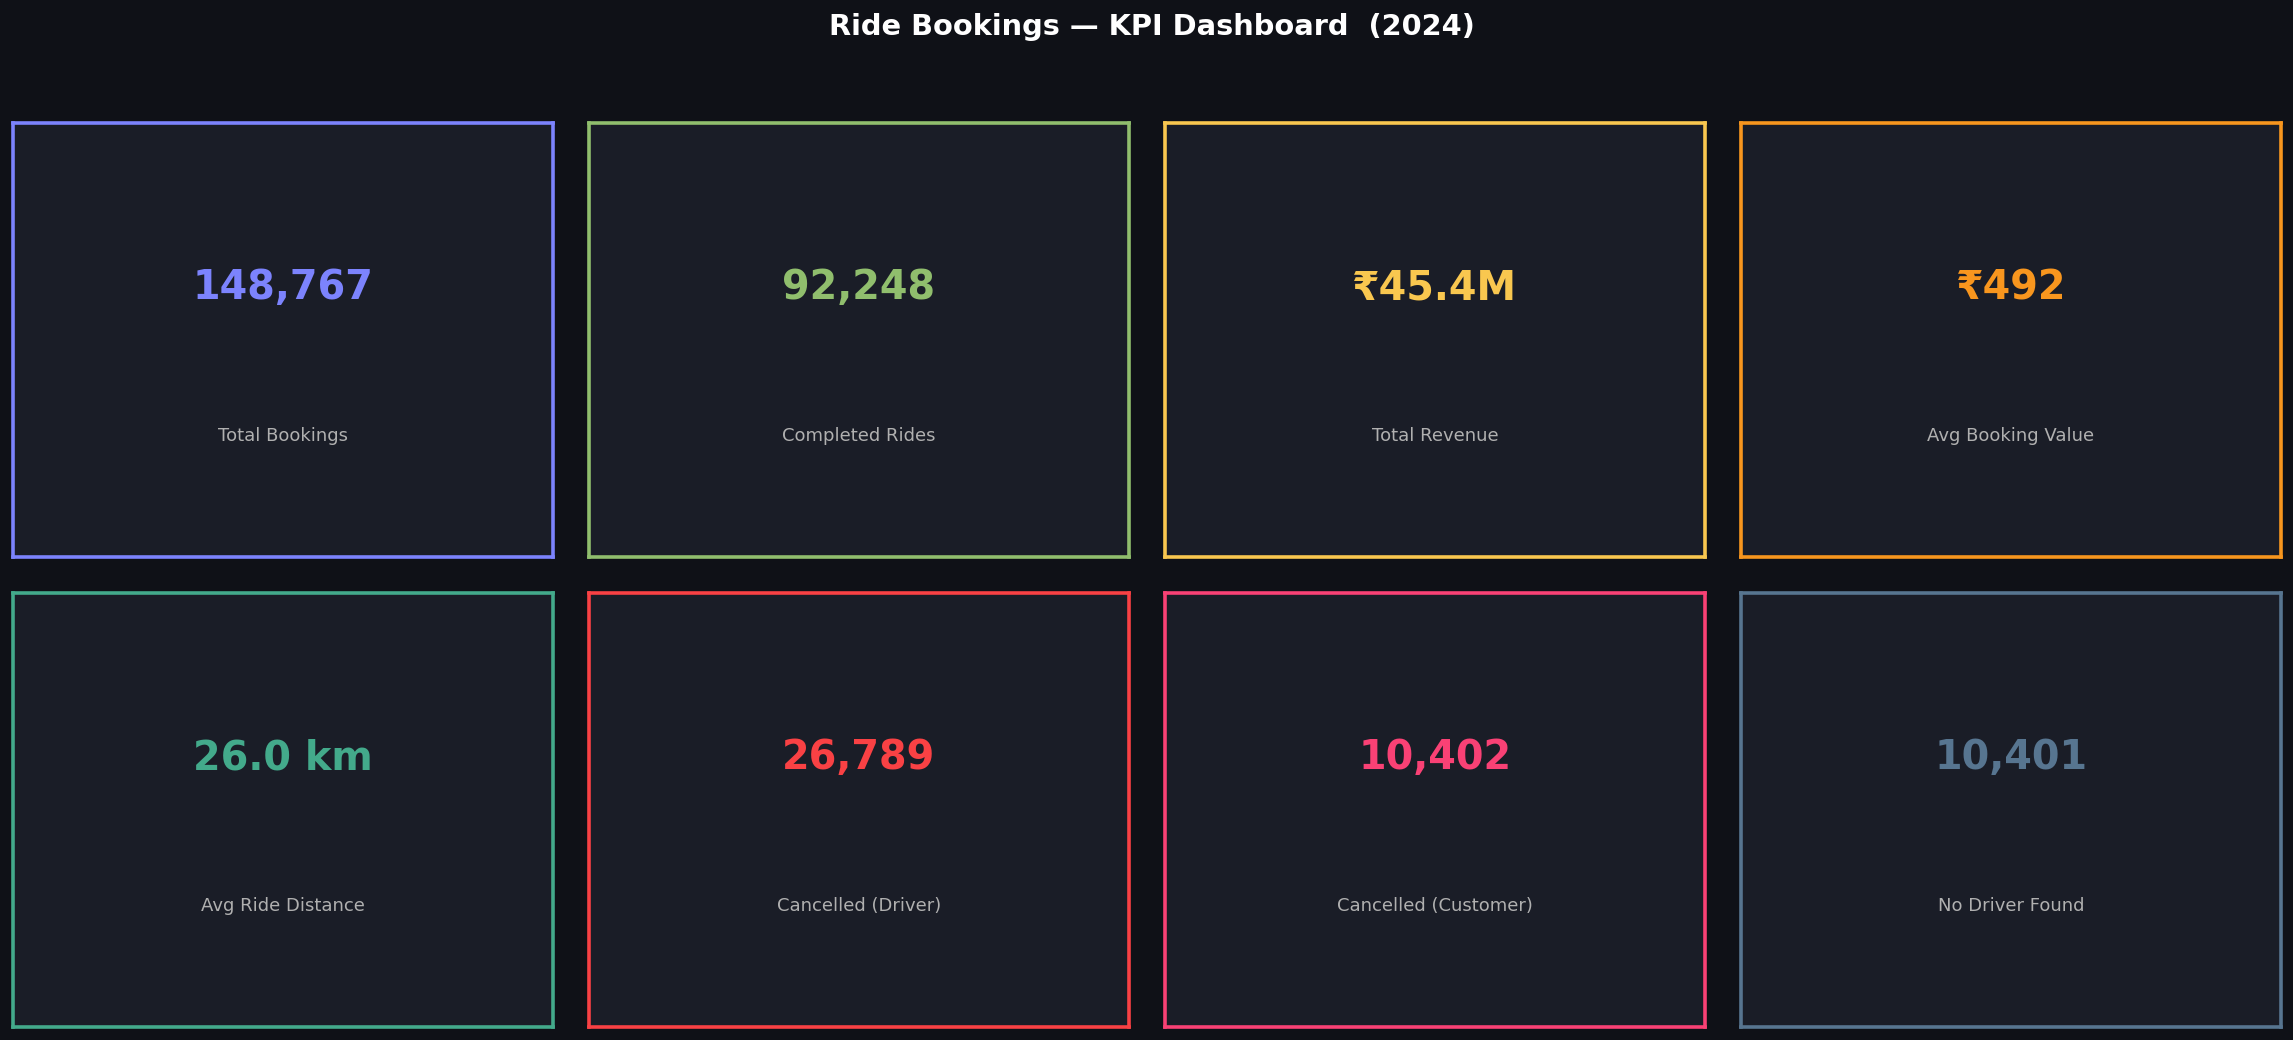

In [5]:
completed   = (df["Booking Status"] == "Completed").sum()
cancelled_c = (df["Booking Status"] == "Cancelled by Customer").sum()
cancelled_d = (df["Booking Status"] == "Cancelled by Driver").sum()
no_driver   = (df["Booking Status"] == "No Driver Found").sum()
incomplete  = (df["Booking Status"] == "Incomplete").sum()
total_rev   = df.loc[df["Booking Status"]=="Completed", "Booking Value"].sum()
avg_rev     = df.loc[df["Booking Status"]=="Completed", "Booking Value"].mean()
avg_dist    = df.loc[df["Booking Status"]=="Completed", "Ride Distance"].mean()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle(" Ride Bookings — KPI Dashboard  (2024)",
             fontsize=16, fontweight="bold", color="#ffffff", y=1.01)

kpis = [
    ("Total Bookings",       f"{len(df):,}",          ACCENT),
    ("Completed Rides",      f"{completed:,}",         SUCCESS),
    ("Total Revenue",        f"₹{total_rev/1e6:.1f}M", ACCENT2),
    ("Avg Booking Value",    f"₹{avg_rev:.0f}",        "#f8961e"),
    ("Avg Ride Distance",    f"{avg_dist:.1f} km",     "#43aa8b"),
    ("Cancelled (Driver)",   f"{cancelled_d:,}",       DANGER),
    ("Cancelled (Customer)", f"{cancelled_c:,}",       "#f94175"),
    ("No Driver Found",      f"{no_driver:,}",         "#577590"),
]
for ax, (label, value, color) in zip(axes.flat, kpis):
    ax.set_facecolor("#1a1d27")
    ax.text(0.5, 0.62, value, ha="center", va="center",
            fontsize=22, fontweight="bold", color=color, transform=ax.transAxes)
    ax.text(0.5, 0.28, label, ha="center", va="center",
            fontsize=10, color="#b0b0b0", transform=ax.transAxes)
    for sp in ax.spines.values():
        sp.set_edgecolor(color); sp.set_linewidth(2)
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout(pad=2)
plt.show()

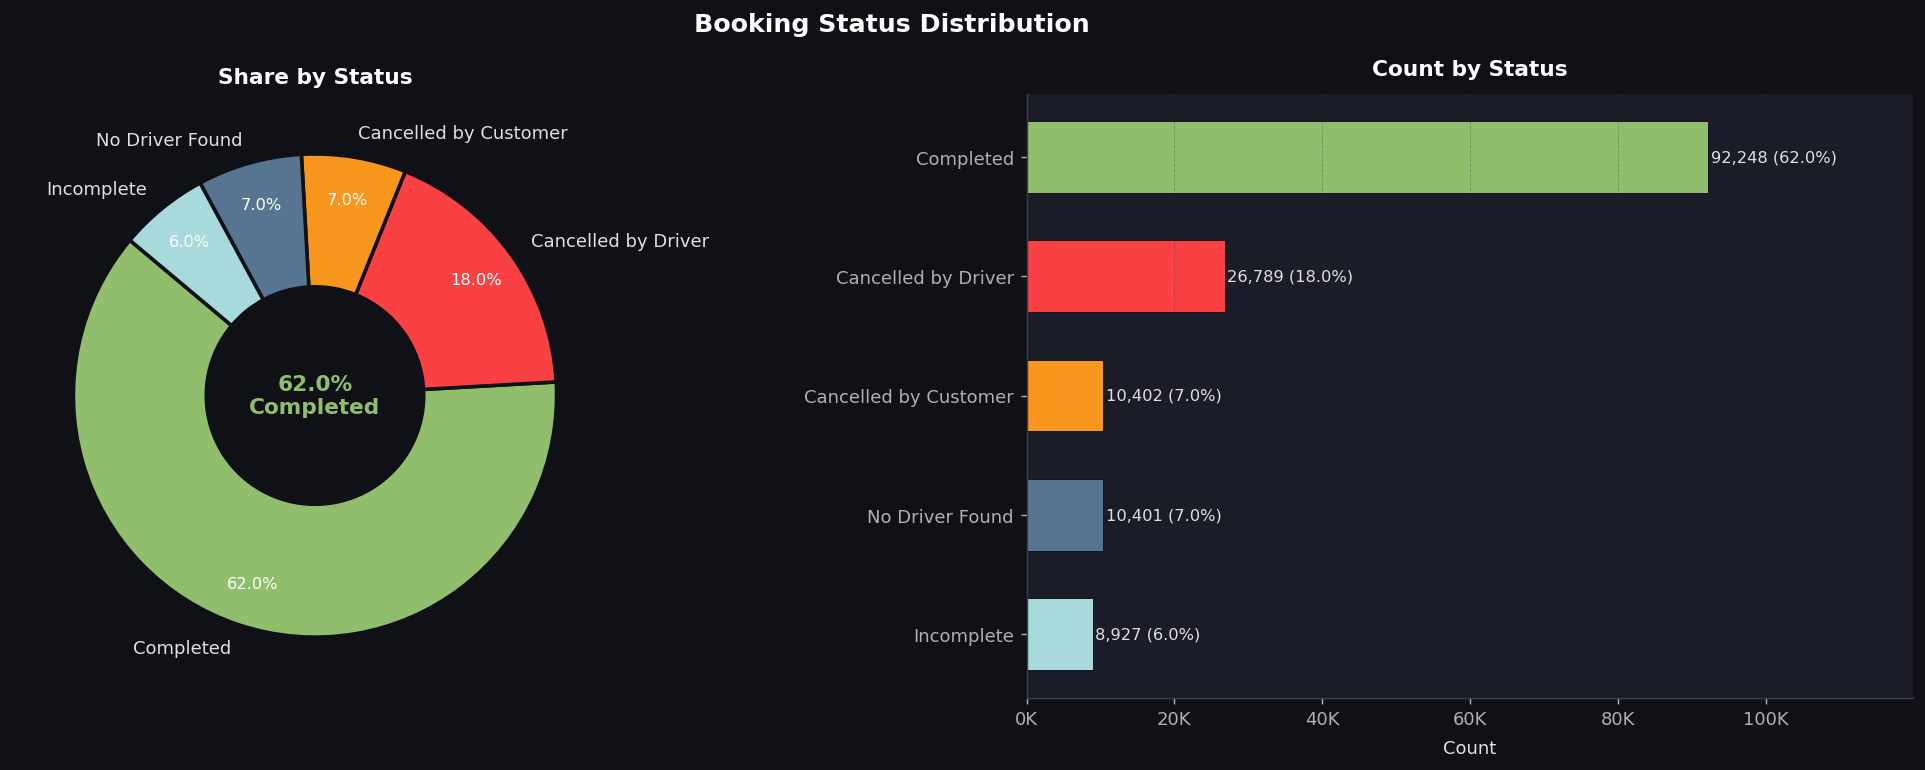

Completion Rate    : 62.01%
Driver Cancel Rate : 18.01%
Customer Cancel    : 6.99%


In [6]:
status_counts = df["Booking Status"].value_counts()
status_colors = [SUCCESS, DANGER, "#f8961e", "#577590", "#a8dadc"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), facecolor="#0f1117")
fig.suptitle("Booking Status Distribution", fontsize=14, fontweight="bold", color="#ffffff")

wedges, texts, autotexts = ax1.pie(
    status_counts.values, labels=status_counts.index,
    colors=status_colors, autopct="%1.1f%%", startangle=140,
    pctdistance=0.82, wedgeprops=dict(width=0.55, edgecolor="#0f1117", linewidth=2))
for at in autotexts: at.set_fontsize(9); at.set_color("white")
for t in texts: t.set_color("#e0e0e0")
ax1.set_title("Share by Status", color="#ffffff", fontweight="bold")
ax1.add_artist(plt.Circle((0,0), 0.45, fc="#0f1117"))
ax1.text(0, 0, f"{completed/len(df)*100:.1f}%\nCompleted",
         ha="center", va="center", fontsize=12, fontweight="bold", color=SUCCESS)

bars = ax2.barh(status_counts.index[::-1], status_counts.values[::-1],
                color=status_colors[::-1], edgecolor="#0f1117", linewidth=0.5, height=0.6)
for bar, val in zip(bars, status_counts.values[::-1]):
    ax2.text(bar.get_width()+300, bar.get_y()+bar.get_height()/2,
             f"{val:,} ({val/len(df)*100:.1f}%)", va="center", fontsize=9, color="#e0e0e0")
style_ax(ax2, "Count by Status", "Count", "", grid="x")
ax2.set_xlim(0, status_counts.max()*1.3)
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{x/1000:.0f}K"))
fig.tight_layout(); plt.show()

print(f"Completion Rate    : {completed/len(df)*100:.2f}%")
print(f"Driver Cancel Rate : {cancelled_d/len(df)*100:.2f}%")
print(f"Customer Cancel    : {cancelled_c/len(df)*100:.2f}%")


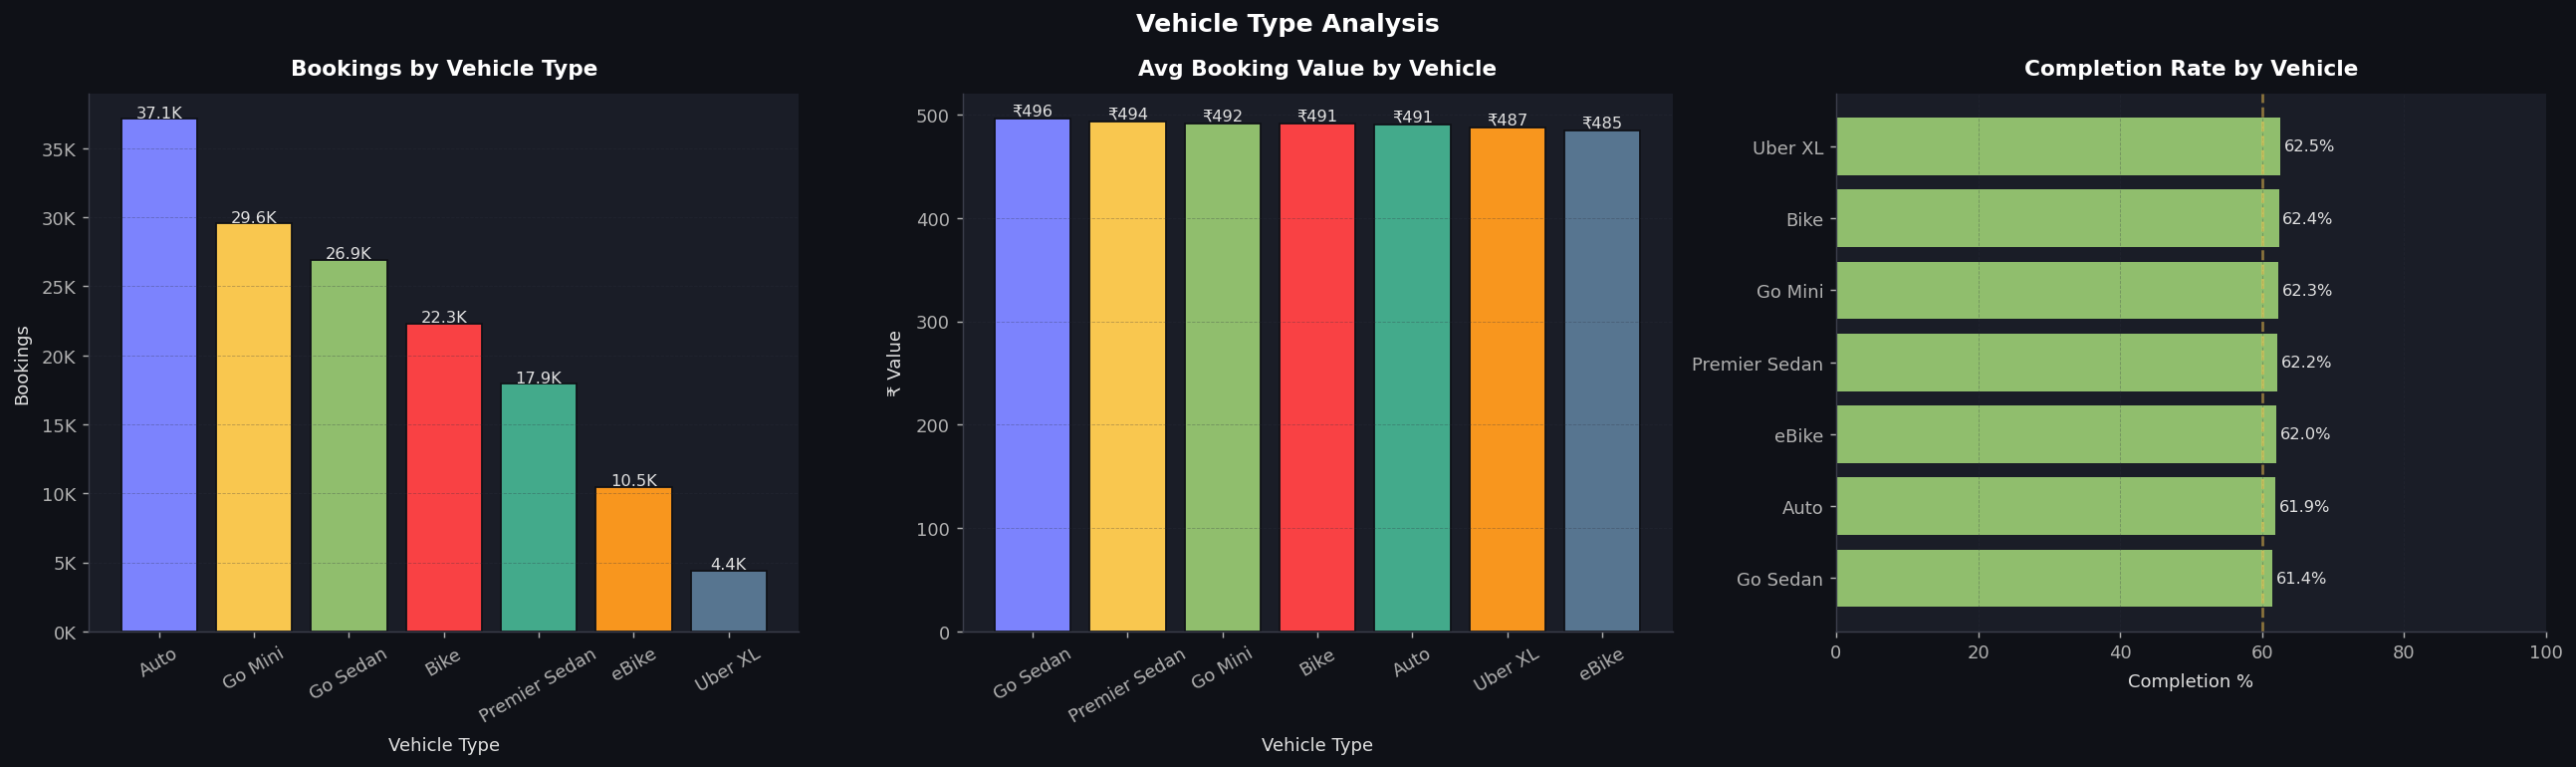

In [7]:
vt     = df["Vehicle Type"].value_counts()
comp   = df[df["Booking Status"]=="Completed"].copy()
vt_rev = comp.groupby("Vehicle Type")["Booking Value"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor="#0f1117")
fig.suptitle("Vehicle Type Analysis", fontsize=14, fontweight="bold", color="#ffffff")

bars = axes[0].bar(vt.index, vt.values, color=PALETTE[:len(vt)], edgecolor="#0f1117")
for bar, val in zip(bars, vt.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f"{val/1000:.1f}K", ha="center", fontsize=9, color="#e0e0e0")
style_ax(axes[0], "Bookings by Vehicle Type", "Vehicle Type", "Bookings")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{x/1000:.0f}K"))
axes[0].tick_params(axis="x", rotation=30)

bars2 = axes[1].bar(vt_rev.index, vt_rev.values, color=PALETTE[:len(vt_rev)], edgecolor="#0f1117")
for bar, val in zip(bars2, vt_rev.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 f"₹{val:.0f}", ha="center", fontsize=9, color="#e0e0e0")
style_ax(axes[1], "Avg Booking Value by Vehicle", "Vehicle Type", "₹ Value")
axes[1].tick_params(axis="x", rotation=30)

comp_rate = df.groupby("Vehicle Type")["Booking Status"].apply(
    lambda x: (x=="Completed").sum()/len(x)*100).sort_values()
bars3 = axes[2].barh(comp_rate.index, comp_rate.values,
                     color=[SUCCESS if v>=60 else DANGER for v in comp_rate.values])
for bar, val in zip(bars3, comp_rate.values):
    axes[2].text(val+0.5, bar.get_y()+bar.get_height()/2,
                 f"{val:.1f}%", va="center", fontsize=9, color="#e0e0e0")
style_ax(axes[2], "Completion Rate by Vehicle", "Completion %", "", grid="x")
axes[2].set_xlim(0, 100)
axes[2].axvline(60, color=ACCENT2, linestyle="--", alpha=0.5)
fig.tight_layout(); plt.show()

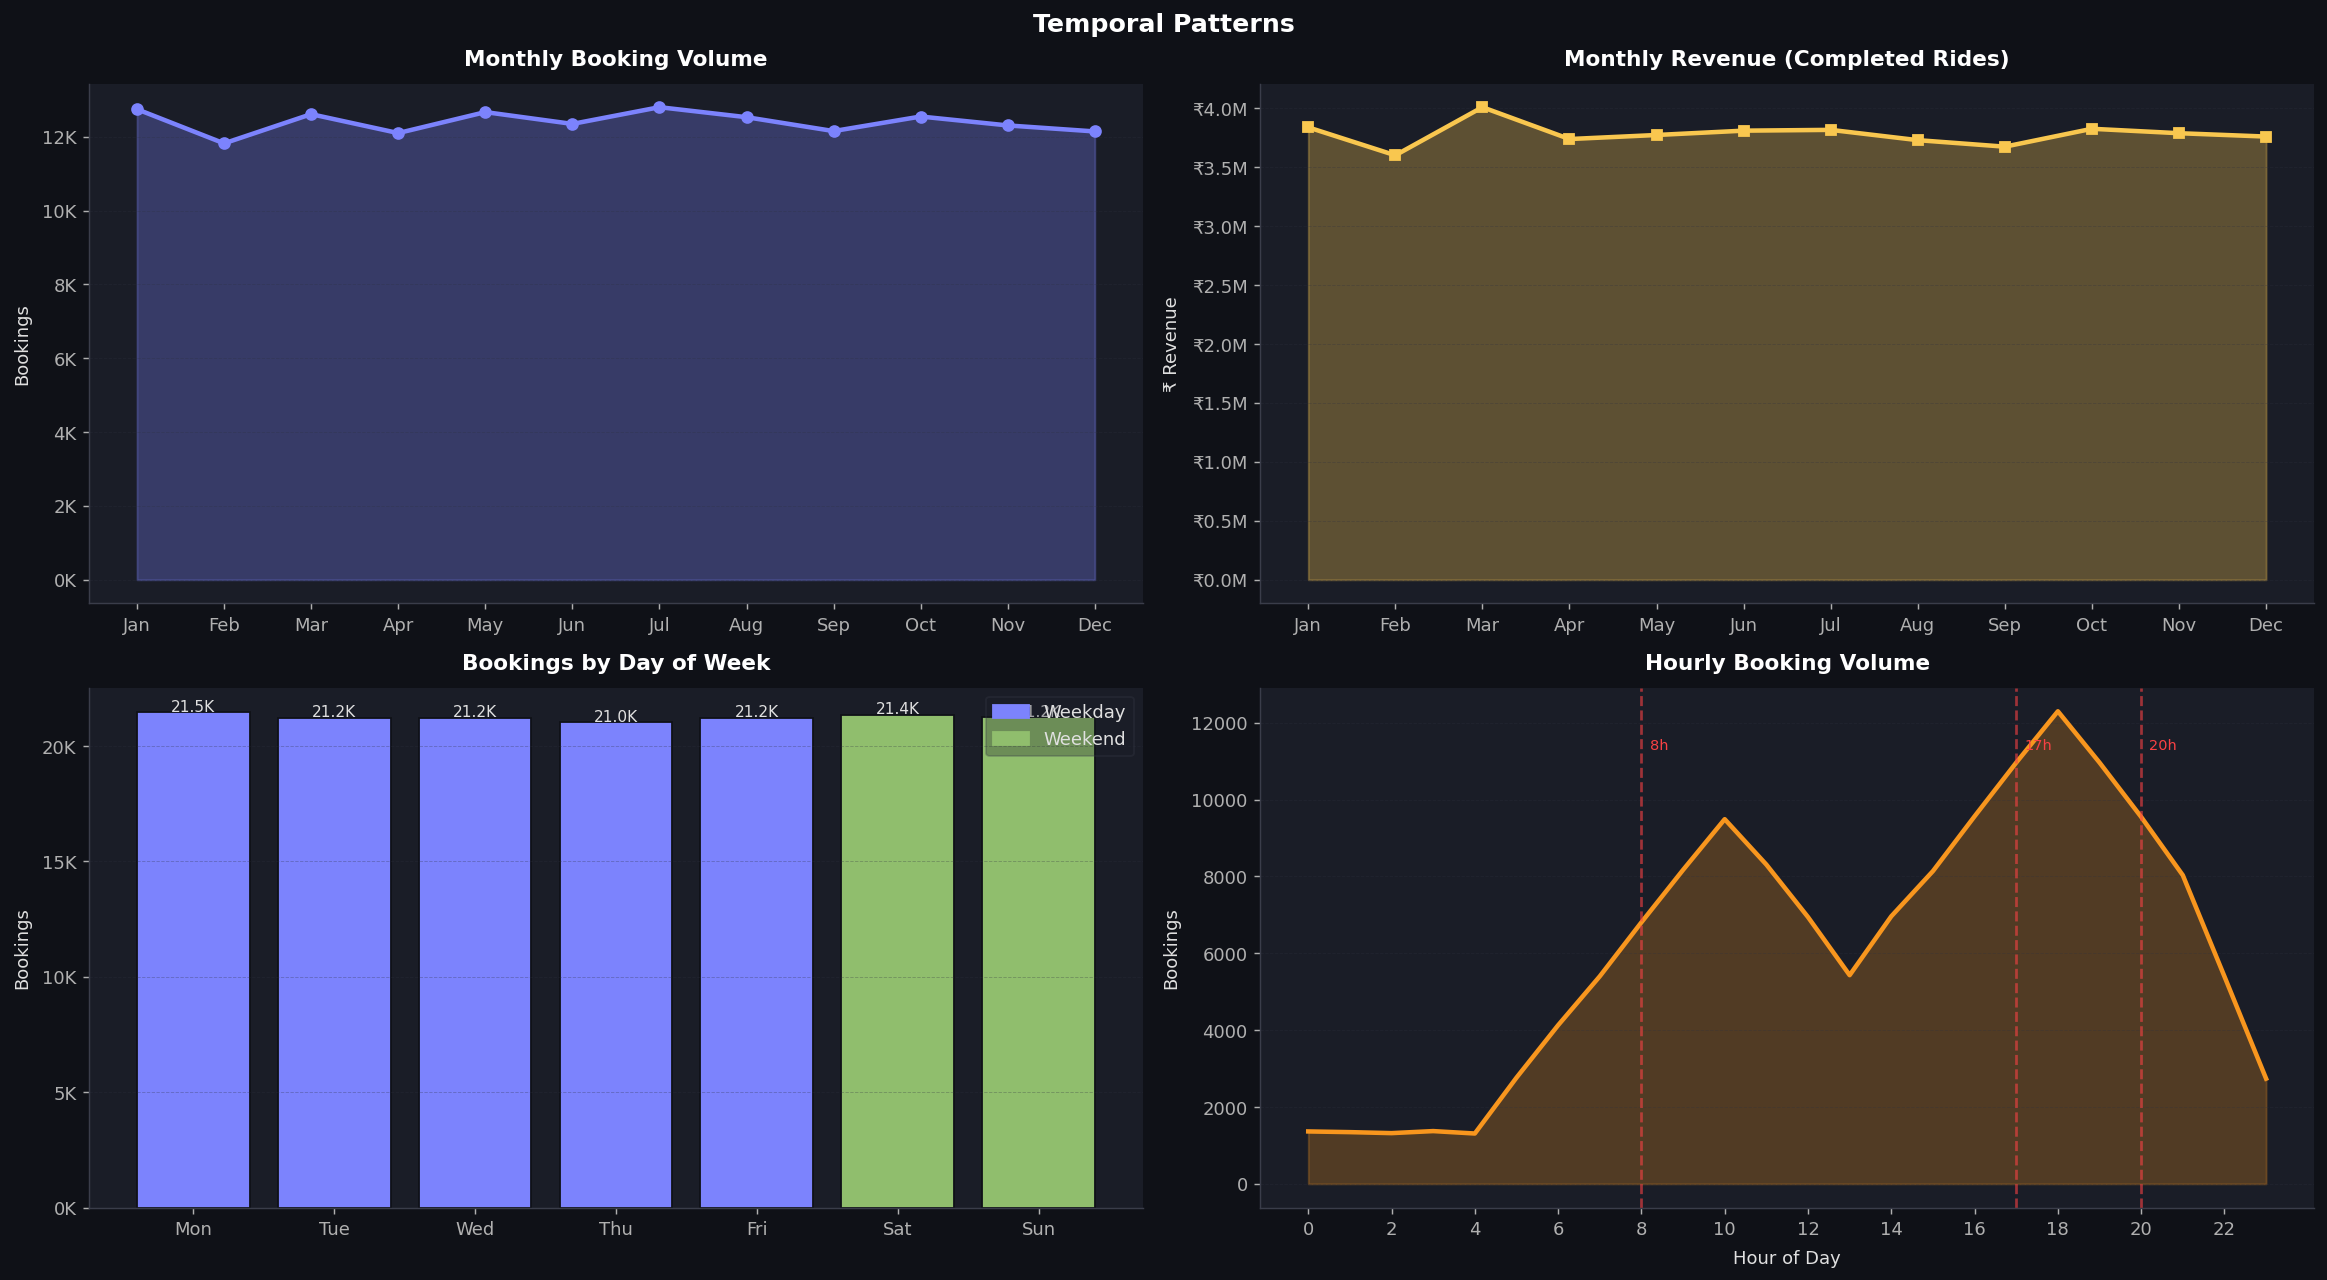

Peak hour    : 18:00  (12,298 bookings)
Busiest day  : Mon  (21,460 bookings)


In [8]:
monthly     = df.groupby("Month").size()
daily       = df.groupby("DayOfWeek").size()
hourly      = df.groupby("Hour").size()
monthly_rev = df[df["Booking Status"]=="Completed"].groupby("Month")["Booking Value"].sum()
months      = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
day_names   = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, axes = plt.subplots(2, 2, figsize=(18, 10), facecolor="#0f1117")
fig.suptitle("Temporal Patterns", fontsize=14, fontweight="bold", color="#ffffff")

axes[0,0].fill_between(range(1,13), monthly.values, alpha=0.3, color=ACCENT)
axes[0,0].plot(range(1,13), monthly.values, color=ACCENT, linewidth=2.5, marker="o", ms=6)
axes[0,0].set_xticks(range(1,13)); axes[0,0].set_xticklabels(months)
style_ax(axes[0,0], "Monthly Booking Volume", "", "Bookings")
axes[0,0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{x/1000:.0f}K"))

axes[0,1].fill_between(range(1,13), monthly_rev.values, alpha=0.3, color=ACCENT2)
axes[0,1].plot(range(1,13), monthly_rev.values, color=ACCENT2, linewidth=2.5, marker="s", ms=6)
axes[0,1].set_xticks(range(1,13)); axes[0,1].set_xticklabels(months)
style_ax(axes[0,1], "Monthly Revenue (Completed Rides)", "", "₹ Revenue")
axes[0,1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"₹{x/1e6:.1f}M"))

bar_colors = [SUCCESS if i>=5 else ACCENT for i in range(7)]
bars = axes[1,0].bar(day_names, daily.values, color=bar_colors, edgecolor="#0f1117")
for bar, val in zip(bars, daily.values):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                   f"{val/1000:.1f}K", ha="center", fontsize=8.5, color="#e0e0e0")
style_ax(axes[1,0], "Bookings by Day of Week", "", "Bookings")
axes[1,0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{x/1000:.0f}K"))
axes[1,0].legend(handles=[mpatches.Patch(color=ACCENT, label="Weekday"),
                            mpatches.Patch(color=SUCCESS, label="Weekend")], loc="upper right")

axes[1,1].fill_between(hourly.index, hourly.values, alpha=0.25, color="#f8961e")
axes[1,1].plot(hourly.index, hourly.values, color="#f8961e", linewidth=2.5)
for peak in [8, 17, 20]:
    axes[1,1].axvline(peak, color=DANGER, linestyle="--", alpha=0.6)
    axes[1,1].text(peak+0.2, hourly.max()*0.92, f"{peak}h", color=DANGER, fontsize=8)
style_ax(axes[1,1], "Hourly Booking Volume", "Hour of Day", "Bookings")
axes[1,1].set_xticks(range(0,24,2))
fig.tight_layout(); plt.show()

print(f"Peak hour    : {hourly.idxmax()}:00  ({hourly.max():,} bookings)")
print(f"Busiest day  : {day_names[daily.idxmax()]}  ({daily.max():,} bookings)")

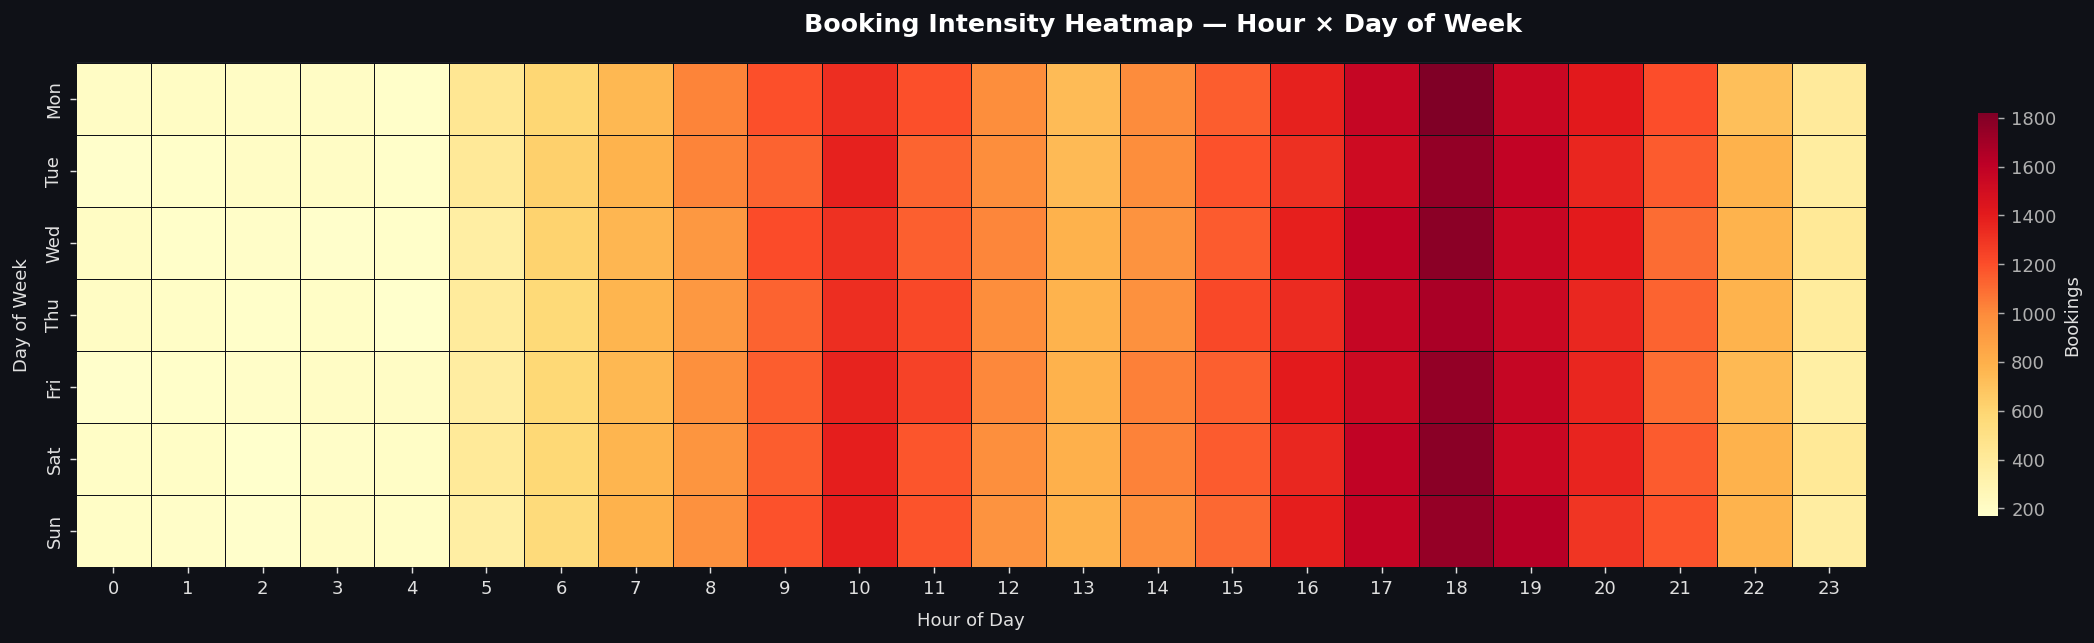

In [9]:
pivot = df.pivot_table(index="DayOfWeek", columns="Hour",
                       values="Booking ID", aggfunc="count")
pivot.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

fig, ax = plt.subplots(figsize=(18, 5), facecolor="#0f1117")
fig.suptitle("Booking Intensity Heatmap — Hour × Day of Week",
             fontsize=14, fontweight="bold", color="#ffffff")
sns.heatmap(pivot, cmap="YlOrRd", ax=ax, linewidths=0.3,
            linecolor="#0f1117", cbar_kws={"label":"Bookings","shrink":0.8}, annot=False)
ax.set_xlabel("Hour of Day", labelpad=8)
ax.set_ylabel("Day of Week", labelpad=8)
ax.tick_params(colors="#e0e0e0")
fig.tight_layout(); plt.show()

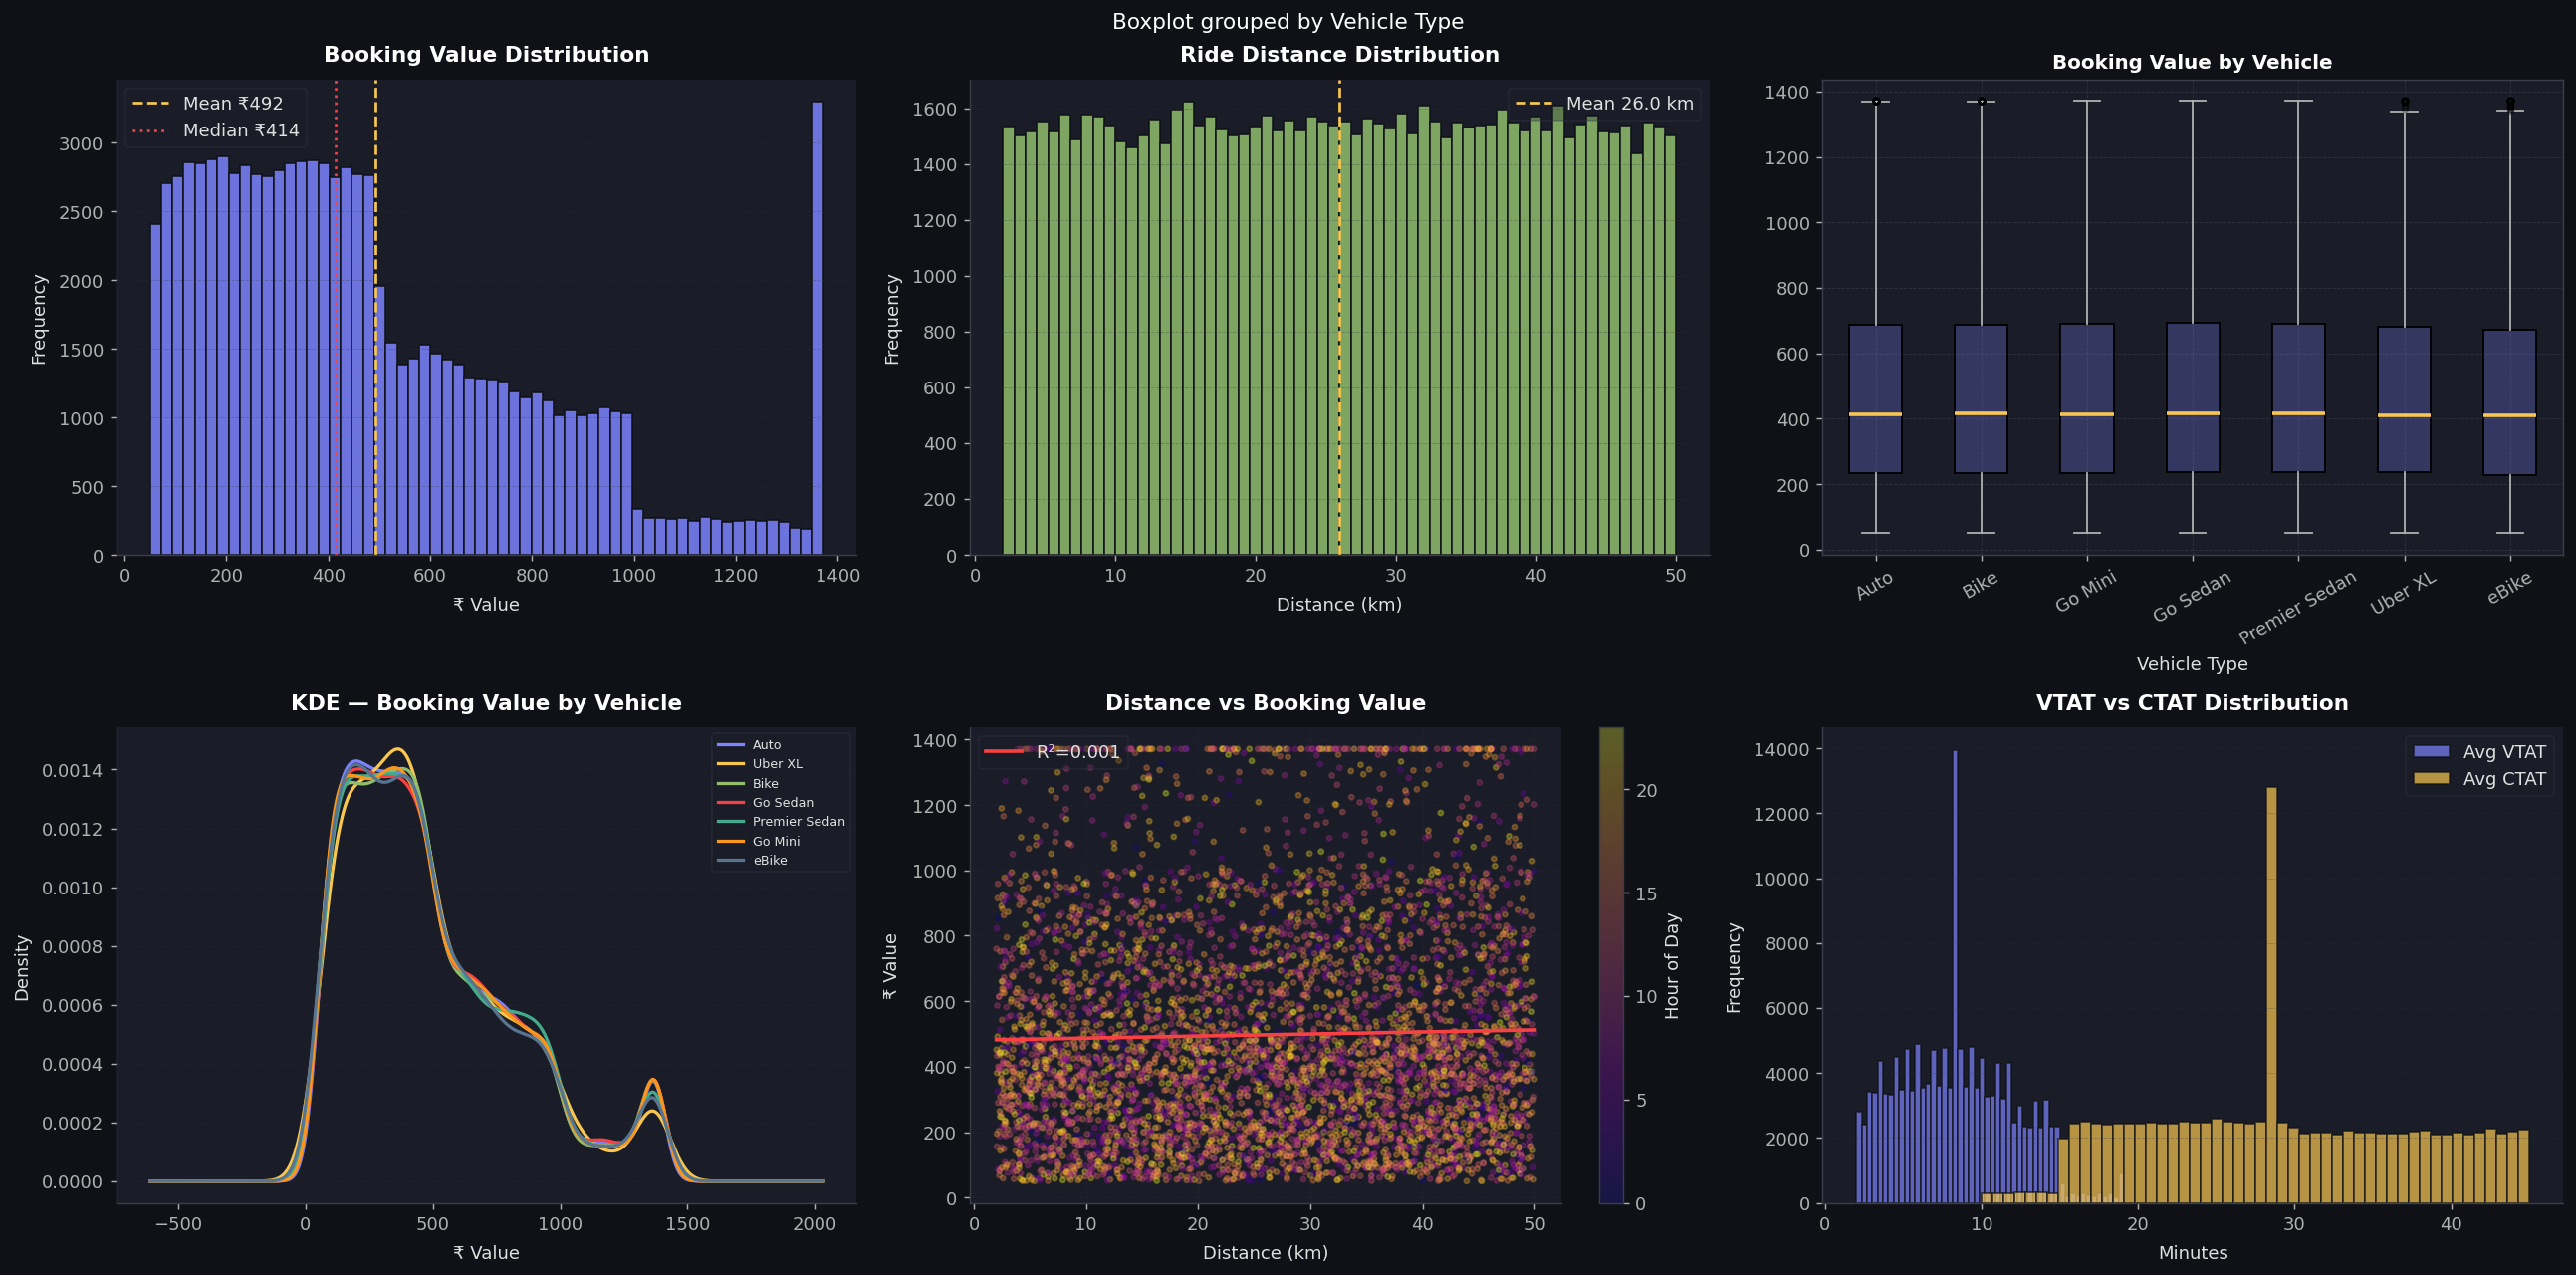

In [10]:
comp = df[df["Booking Status"]=="Completed"].copy()

fig, axes = plt.subplots(2, 3, figsize=(20, 10), facecolor="#0f1117")
fig.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold", color="#ffffff")

axes[0,0].hist(comp["Booking Value"].dropna(), bins=60, color=ACCENT, edgecolor="#0f1117", alpha=0.85)
axes[0,0].axvline(comp["Booking Value"].mean(), color=ACCENT2, linestyle="--", linewidth=1.5,
                  label=f'Mean ₹{comp["Booking Value"].mean():.0f}')
axes[0,0].axvline(comp["Booking Value"].median(), color=DANGER, linestyle=":", linewidth=1.5,
                  label=f'Median ₹{comp["Booking Value"].median():.0f}')
style_ax(axes[0,0], "Booking Value Distribution", "₹ Value", "Frequency"); axes[0,0].legend()

axes[0,1].hist(comp["Ride Distance"].dropna(), bins=60, color=SUCCESS, edgecolor="#0f1117", alpha=0.85)
axes[0,1].axvline(comp["Ride Distance"].mean(), color=ACCENT2, linestyle="--", linewidth=1.5,
                  label=f'Mean {comp["Ride Distance"].mean():.1f} km')
style_ax(axes[0,1], "Ride Distance Distribution", "Distance (km)", "Frequency"); axes[0,1].legend()

comp.boxplot(column="Booking Value", by="Vehicle Type", ax=axes[0,2], patch_artist=True,
             medianprops=dict(color=ACCENT2, linewidth=2),
             boxprops=dict(facecolor=ACCENT+"44"),
             whiskerprops=dict(color="#b0b0b0"), capprops=dict(color="#b0b0b0"),
             flierprops=dict(marker=".", alpha=0.3, color=ACCENT))
axes[0,2].set_title("Booking Value by Vehicle", color="#ffffff", fontsize=11, fontweight="bold")
plt.title(""); axes[0,2].tick_params(axis="x", rotation=30)

for i, veh in enumerate(df["Vehicle Type"].unique()):
    comp[comp["Vehicle Type"]==veh]["Booking Value"].dropna().plot(
        kind="kde", ax=axes[1,0], color=PALETTE[i], label=veh, linewidth=1.8)
style_ax(axes[1,0], "KDE — Booking Value by Vehicle", "₹ Value", "Density"); axes[1,0].legend(fontsize=7)

sample = comp.sample(min(5000, len(comp)), random_state=42)
sc = axes[1,1].scatter(sample["Ride Distance"], sample["Booking Value"],
                       alpha=0.3, s=8, c=sample["Hour"], cmap="plasma")
plt.colorbar(sc, ax=axes[1,1], label="Hour of Day")
m, b, r, p, _ = stats.linregress(sample["Ride Distance"].dropna(), sample["Booking Value"].dropna())
x_line = np.linspace(sample["Ride Distance"].min(), sample["Ride Distance"].max(), 100)
axes[1,1].plot(x_line, m*x_line+b, color=DANGER, linewidth=2, label=f"R²={r**2:.3f}")
style_ax(axes[1,1], "Distance vs Booking Value", "Distance (km)", "₹ Value", grid="both")
axes[1,1].legend()

axes[1,2].hist(df["Avg VTAT"].dropna(), bins=50, color=ACCENT, alpha=0.7, edgecolor="#0f1117", label="Avg VTAT")
axes[1,2].hist(df["Avg CTAT"].dropna(), bins=50, color=ACCENT2, alpha=0.7, edgecolor="#0f1117", label="Avg CTAT")
style_ax(axes[1,2], "VTAT vs CTAT Distribution", "Minutes", "Frequency"); axes[1,2].legend()
fig.tight_layout(); plt.show()

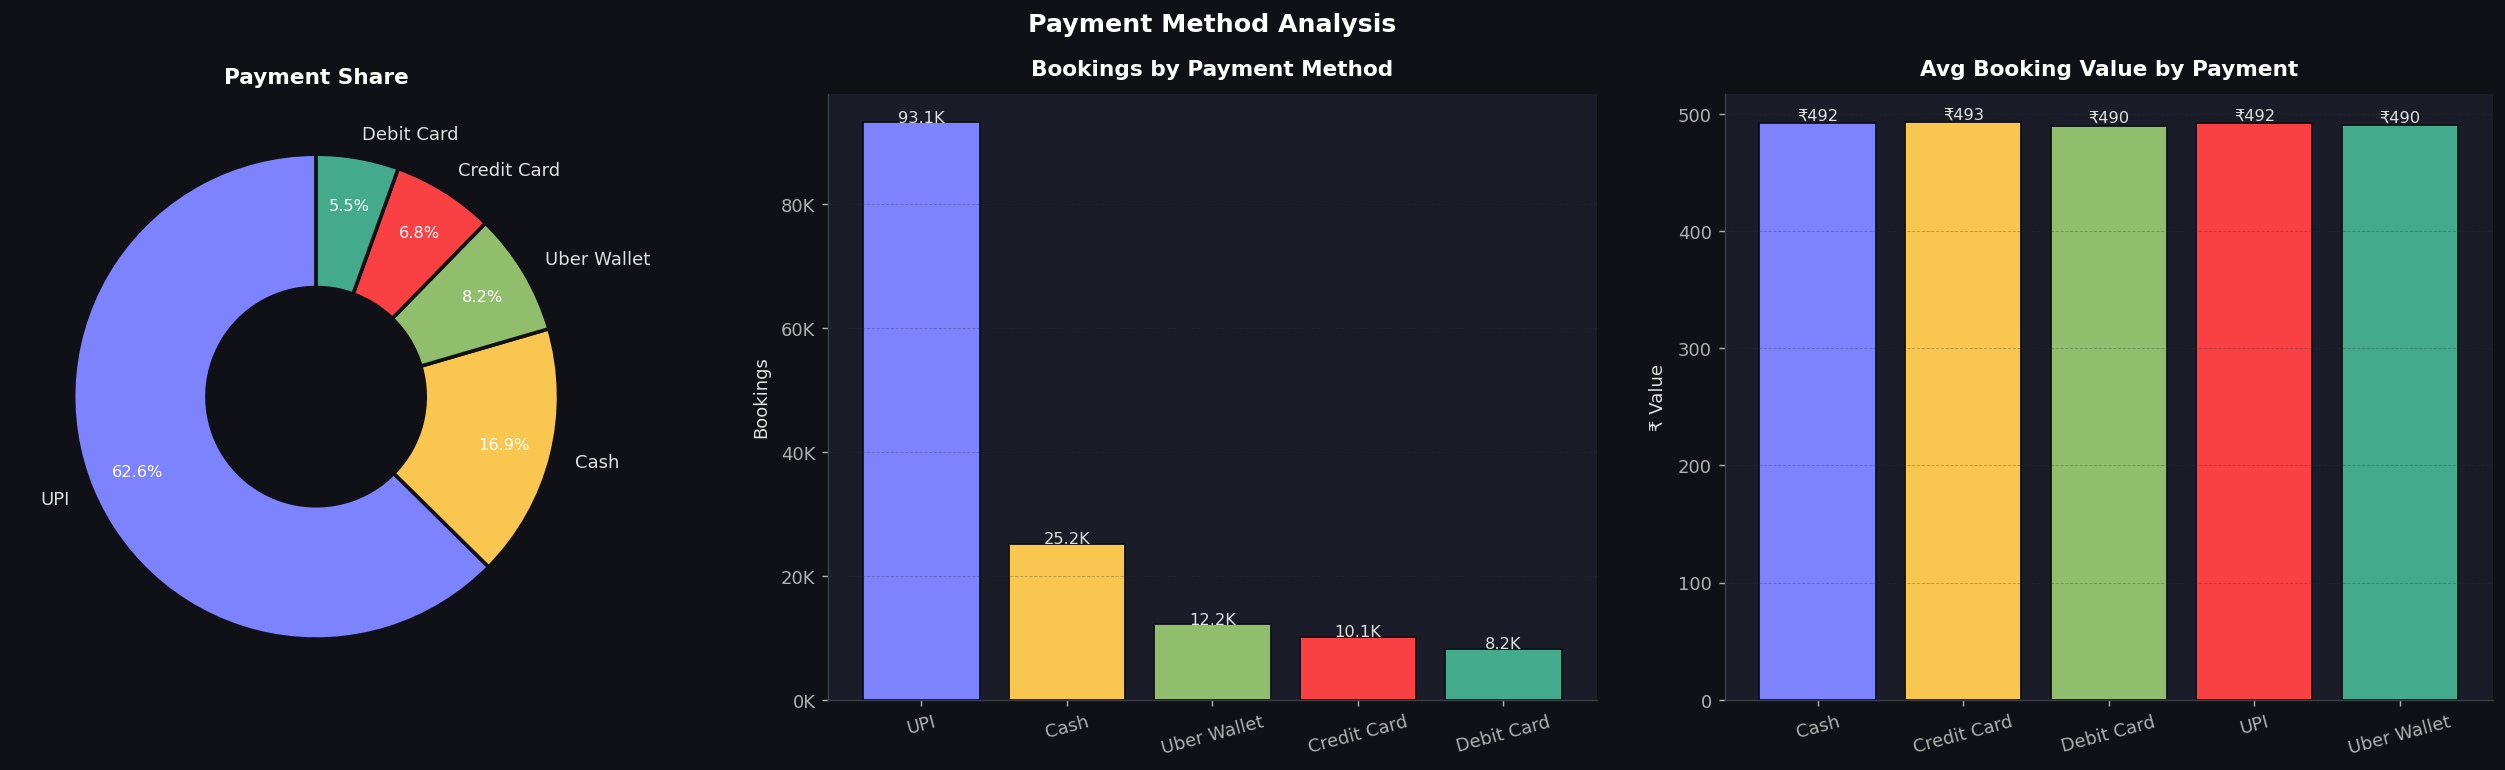

In [11]:
pay     = df["Payment Method"].value_counts()
pay_rev = df[df["Booking Status"]=="Completed"].groupby("Payment Method")["Booking Value"].mean()

fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor="#0f1117")
fig.suptitle("Payment Method Analysis", fontsize=14, fontweight="bold", color="#ffffff")

wedges, _, autotexts = axes[0].pie(pay, labels=pay.index, autopct="%1.1f%%",
                                    colors=PALETTE[:len(pay)], startangle=90,
                                    pctdistance=0.8,
                                    wedgeprops=dict(width=0.55, edgecolor="#0f1117", linewidth=2))
for at in autotexts: at.set_fontsize(9); at.set_color("white")
axes[0].set_title("Payment Share", color="#ffffff", fontweight="bold")
axes[0].add_artist(plt.Circle((0,0), 0.45, fc="#0f1117"))

bars = axes[1].bar(pay.index, pay.values, color=PALETTE[:len(pay)], edgecolor="#0f1117")
for bar, v in zip(bars, pay.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f"{v/1000:.1f}K", ha="center", fontsize=9, color="#e0e0e0")
style_ax(axes[1], "Bookings by Payment Method", "", "Bookings")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"{x/1000:.0f}K"))
axes[1].tick_params(axis="x", rotation=15)

bars2 = axes[2].bar(pay_rev.index, pay_rev.values, color=PALETTE[:len(pay_rev)], edgecolor="#0f1117")
for bar, v in zip(bars2, pay_rev.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                 f"₹{v:.0f}", ha="center", fontsize=9, color="#e0e0e0")
style_ax(axes[2], "Avg Booking Value by Payment", "", "₹ Value")
axes[2].tick_params(axis="x", rotation=15)
fig.tight_layout(); plt.show()

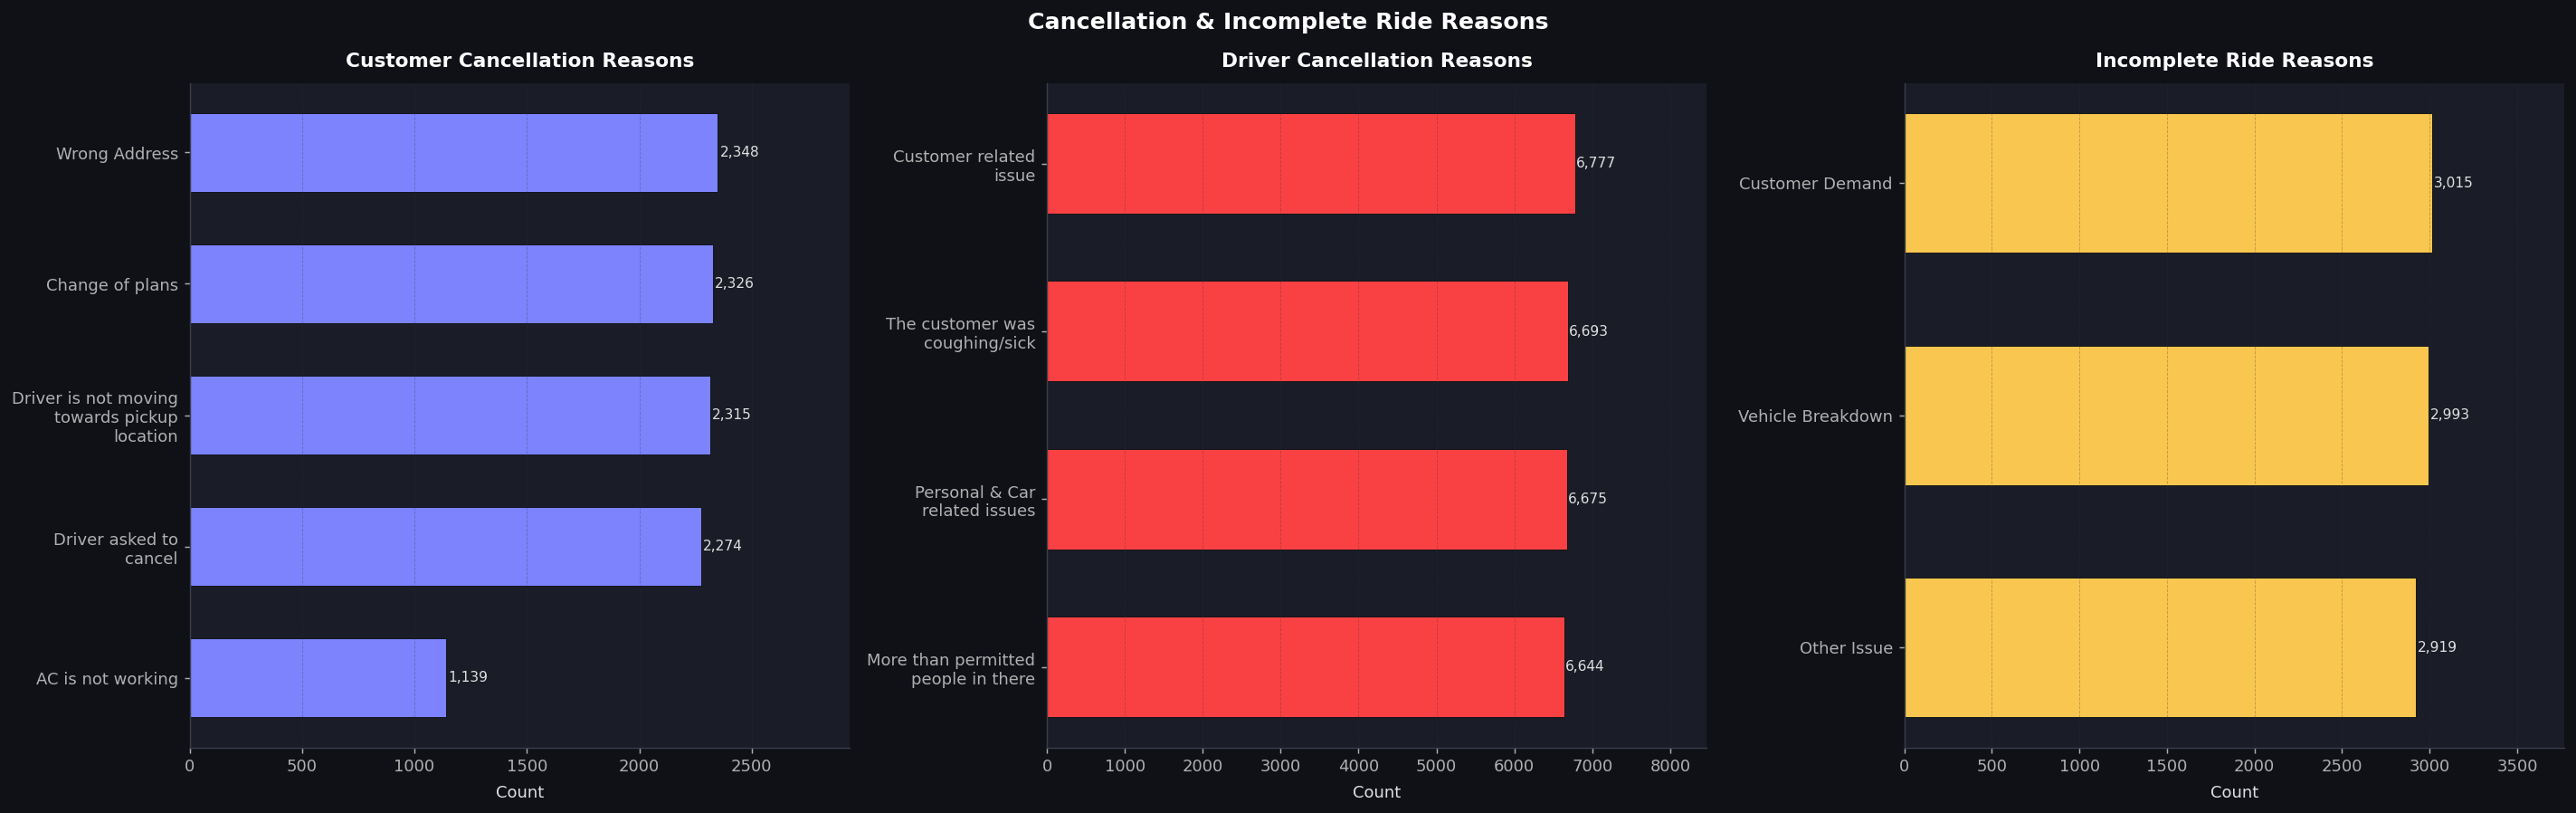

In [12]:
cust_cancel = df["Reason for cancelling by Customer"].dropna().value_counts()
driv_cancel = df["Driver Cancellation Reason"].dropna().value_counts()
incomp_r    = df["Incomplete Rides Reason"].dropna().value_counts()

fig, axes = plt.subplots(1, 3, figsize=(22, 7), facecolor="#0f1117")
fig.suptitle("Cancellation & Incomplete Ride Reasons", fontsize=14, fontweight="bold", color="#ffffff")

for ax, data, title, color in zip(axes,
    [cust_cancel, driv_cancel, incomp_r],
    ["Customer Cancellation Reasons","Driver Cancellation Reasons","Incomplete Ride Reasons"],
    [ACCENT, DANGER, ACCENT2]):
    wrapped = [textwrap.fill(str(l), 20) for l in data.index]
    bars = ax.barh(wrapped[::-1], data.values[::-1],
                   color=color, edgecolor="#0f1117", linewidth=0.5, height=0.6)
    for bar, v in zip(bars, data.values[::-1]):
        ax.text(bar.get_width()+10, bar.get_y()+bar.get_height()/2,
                f"{v:,}", va="center", fontsize=8.5, color="#e0e0e0")
    style_ax(ax, title, "Count", "", grid="x")
    ax.set_xlim(0, data.max()*1.25)
fig.tight_layout(); plt.show()

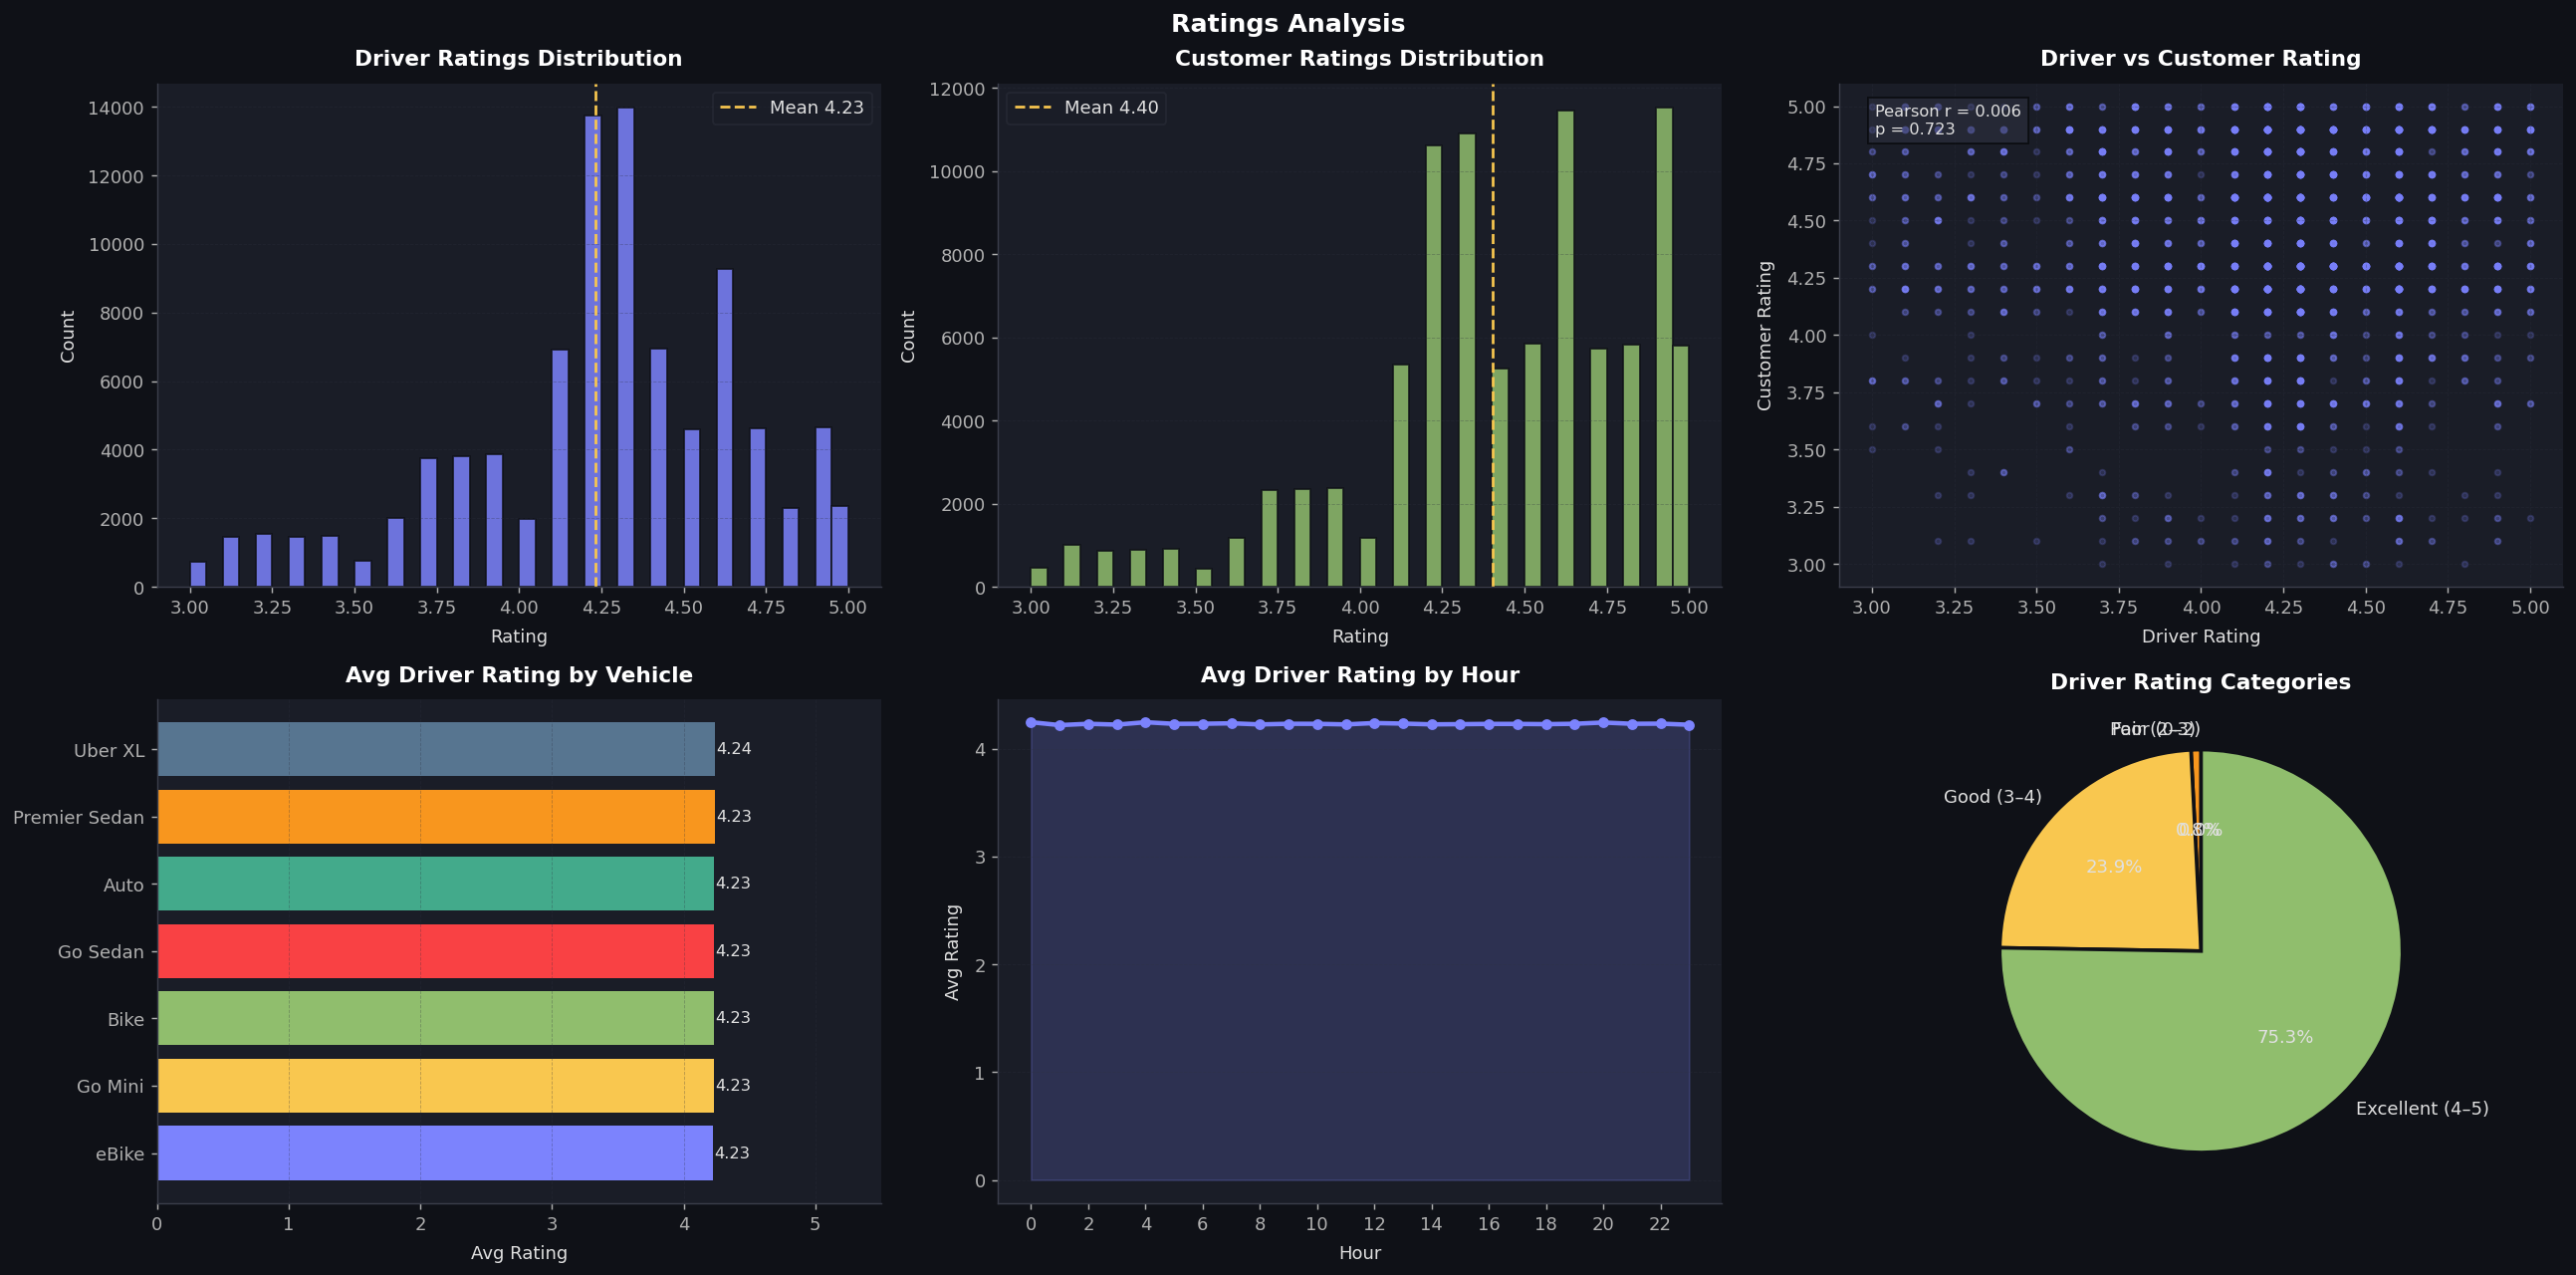

Avg Driver Rating   : 4.23  |  Std: 0.44
Avg Customer Rating : 4.40  |  Std: 0.44
Pearson r (Driver vs Customer): 0.006


In [13]:
comp = df[df["Booking Status"]=="Completed"].copy()
dr   = comp["Driver Ratings"].dropna()
cr   = comp["Customer Rating"].dropna()

fig, axes = plt.subplots(2, 3, figsize=(20, 10), facecolor="#0f1117")
fig.suptitle("Ratings Analysis", fontsize=14, fontweight="bold", color="#ffffff")

axes[0,0].hist(dr, bins=40, color=ACCENT, edgecolor="#0f1117", alpha=0.85)
axes[0,0].axvline(dr.mean(), color=ACCENT2, linestyle="--", linewidth=1.5, label=f"Mean {dr.mean():.2f}")
style_ax(axes[0,0], "Driver Ratings Distribution", "Rating", "Count"); axes[0,0].legend()

axes[0,1].hist(cr, bins=40, color=SUCCESS, edgecolor="#0f1117", alpha=0.85)
axes[0,1].axvline(cr.mean(), color=ACCENT2, linestyle="--", linewidth=1.5, label=f"Mean {cr.mean():.2f}")
style_ax(axes[0,1], "Customer Ratings Distribution", "Rating", "Count"); axes[0,1].legend()

sample2 = comp[["Driver Ratings","Customer Rating"]].dropna().sample(min(3000,len(comp)), random_state=42)
axes[0,2].scatter(sample2["Driver Ratings"], sample2["Customer Rating"], alpha=0.2, s=10, color=ACCENT)
r_val, pval = stats.pearsonr(sample2["Driver Ratings"], sample2["Customer Rating"])
axes[0,2].text(0.05, 0.9, f"Pearson r = {r_val:.3f}\np = {pval:.3f}",
               transform=axes[0,2].transAxes, fontsize=9, color="#e0e0e0",
               bbox=dict(facecolor="#2e3140", alpha=0.6))
style_ax(axes[0,2], "Driver vs Customer Rating", "Driver Rating", "Customer Rating", grid="both")

dr_veh = comp.groupby("Vehicle Type")["Driver Ratings"].mean().sort_values()
axes[1,0].barh(dr_veh.index, dr_veh.values, color=PALETTE[:len(dr_veh)])
for i, v in enumerate(dr_veh.values):
    axes[1,0].text(v+0.01, i, f"{v:.2f}", va="center", fontsize=9, color="#e0e0e0")
style_ax(axes[1,0], "Avg Driver Rating by Vehicle", "Avg Rating", "", grid="x")
axes[1,0].set_xlim(0, 5.5)

hr_rating = comp.groupby("Hour")["Driver Ratings"].mean()
axes[1,1].plot(hr_rating.index, hr_rating.values, color=ACCENT, linewidth=2.5, marker="o", ms=5)
axes[1,1].fill_between(hr_rating.index, hr_rating.values, alpha=0.2, color=ACCENT)
style_ax(axes[1,1], "Avg Driver Rating by Hour", "Hour", "Avg Rating")
axes[1,1].set_xticks(range(0,24,2))

bins_   = [0, 2, 3, 4, 5]
labels_ = ["Poor (0–2)","Fair (2–3)","Good (3–4)","Excellent (4–5)"]
comp["Rating Cat"] = pd.cut(comp["Driver Ratings"], bins=bins_, labels=labels_, include_lowest=True)
rcat = comp["Rating Cat"].value_counts().sort_index()
axes[1,2].pie(rcat, labels=rcat.index, autopct="%1.1f%%",
              colors=[DANGER,"#f8961e",ACCENT2,SUCCESS],
              startangle=90, wedgeprops=dict(edgecolor="#0f1117", linewidth=2))
axes[1,2].set_title("Driver Rating Categories", color="#ffffff", fontweight="bold")
fig.tight_layout(); plt.show()

print(f"Avg Driver Rating   : {dr.mean():.2f}  |  Std: {dr.std():.2f}")
print(f"Avg Customer Rating : {cr.mean():.2f}  |  Std: {cr.std():.2f}")
print(f"Pearson r (Driver vs Customer): {r_val:.3f}")

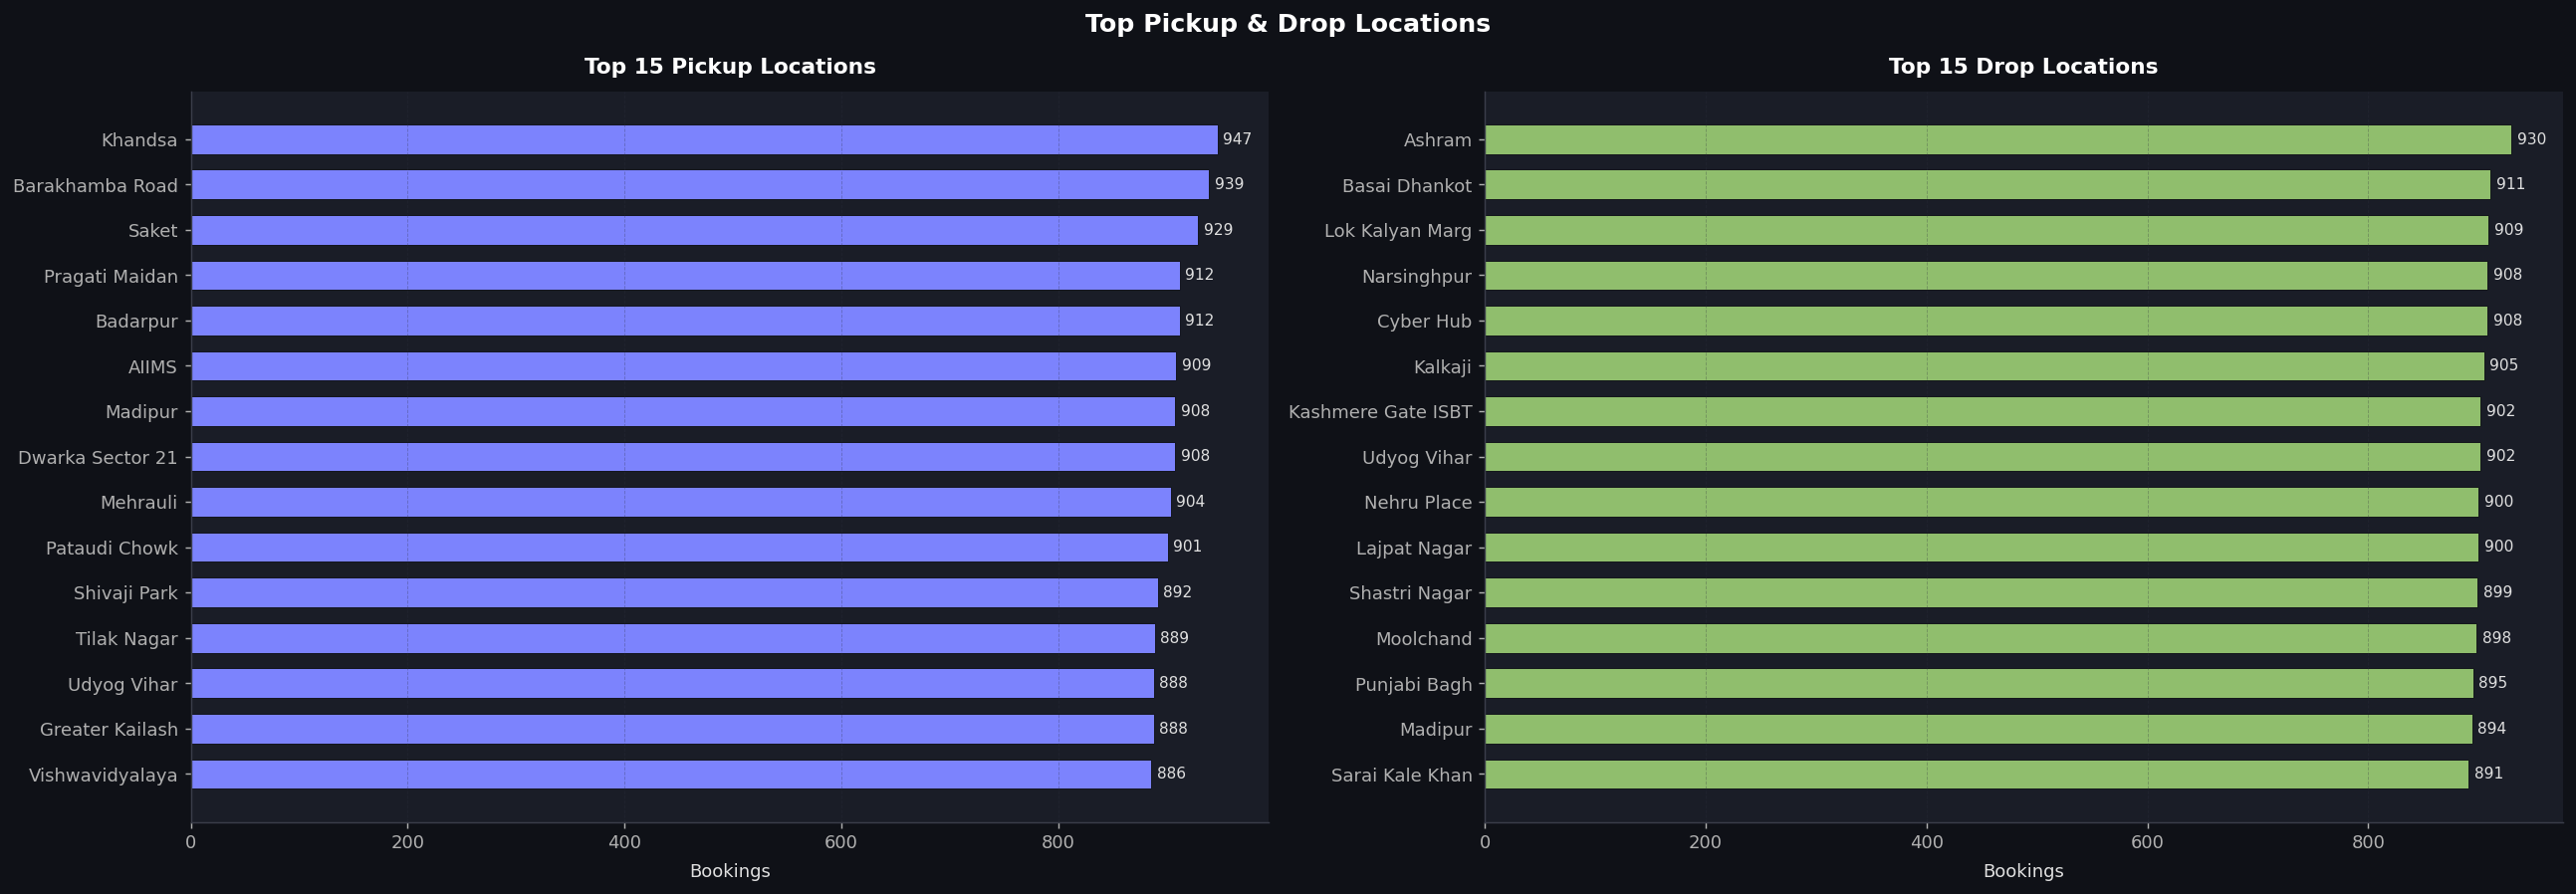

In [14]:
top_pickup = df["Pickup Location"].value_counts().head(15)
top_drop   = df["Drop Location"].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(20, 7), facecolor="#0f1117")
fig.suptitle("Top Pickup & Drop Locations", fontsize=14, fontweight="bold", color="#ffffff")

for ax, data, title, color in zip(axes,
    [top_pickup, top_drop],
    ["Top 15 Pickup Locations","Top 15 Drop Locations"],
    [ACCENT, SUCCESS]):
    bars = ax.barh(data.index[::-1], data.values[::-1],
                   color=color, edgecolor="#0f1117", linewidth=0.5, height=0.65)
    for bar, v in zip(bars, data.values[::-1]):
        ax.text(bar.get_width()+5, bar.get_y()+bar.get_height()/2,
                f"{v:,}", va="center", fontsize=8.5, color="#e0e0e0")
    style_ax(ax, title, "Bookings", "", grid="x")
fig.tight_layout(); plt.show()


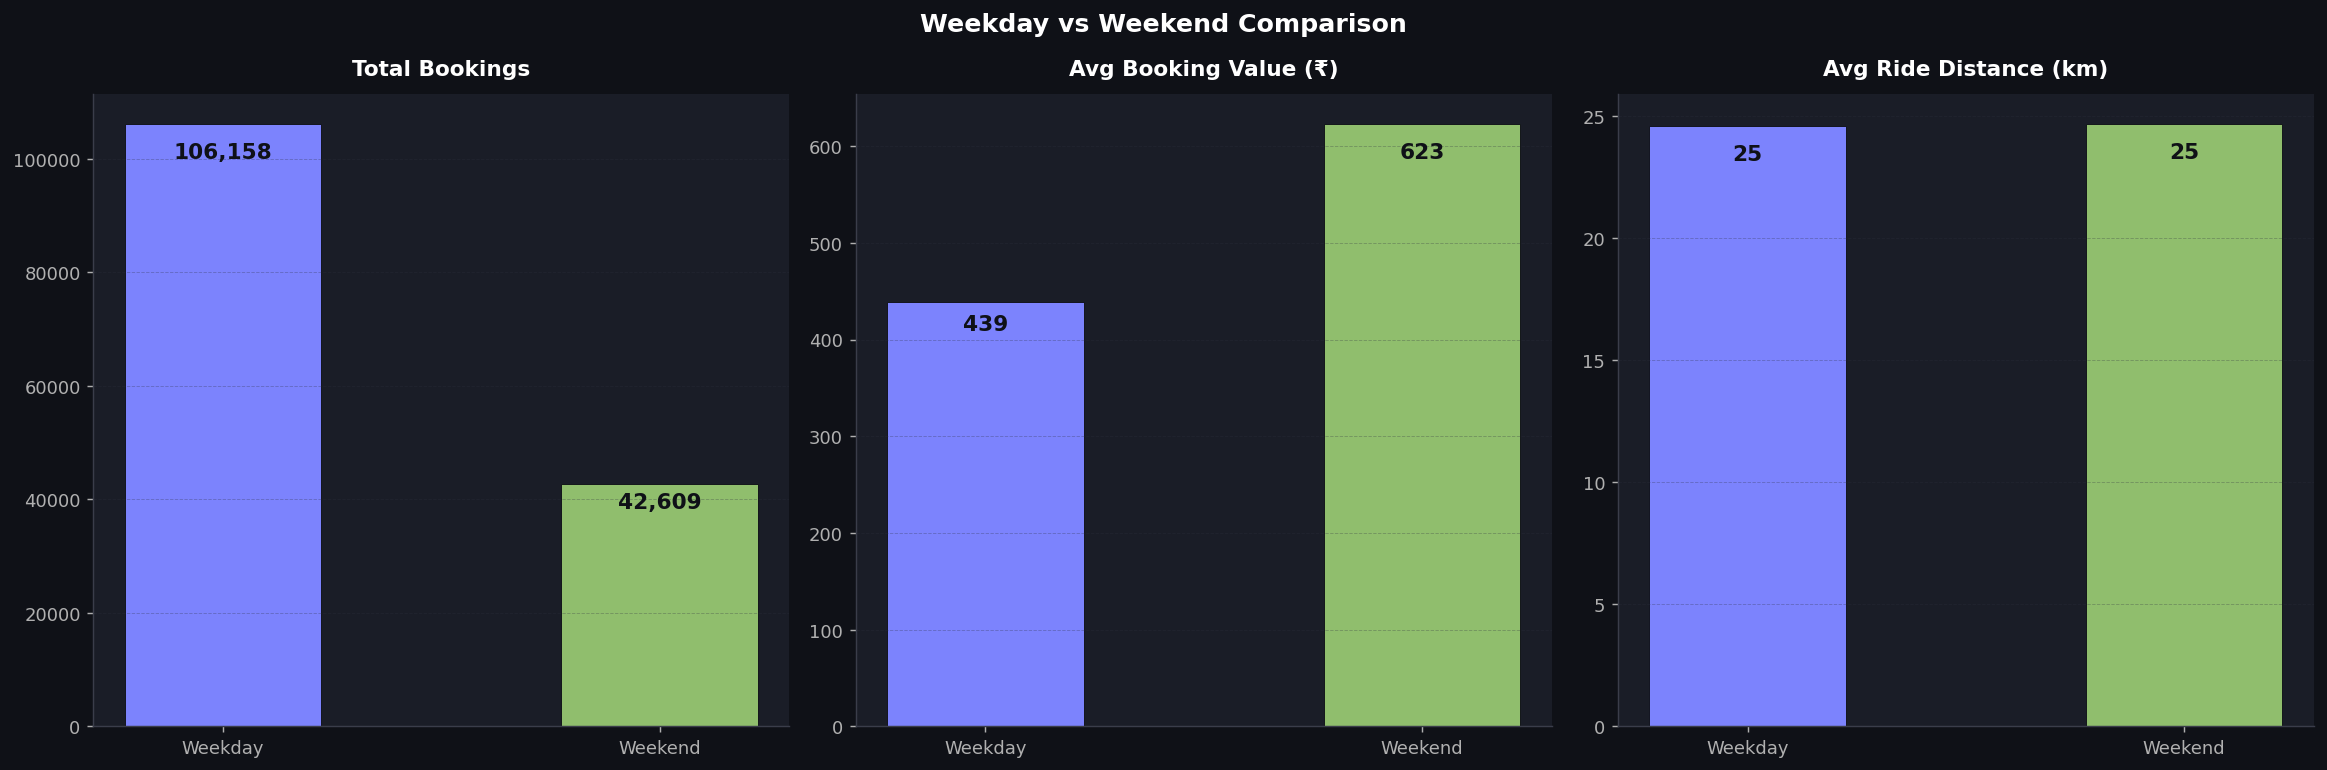

In [15]:
wknd = df.groupby("IsWeekend").agg(
    Bookings=("Booking ID","count"),
    Avg_Value=("Booking Value","mean"),
    Avg_Distance=("Ride Distance","mean")).reset_index()
wknd["Label"] = wknd["IsWeekend"].map({0:"Weekday",1:"Weekend"})

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor="#0f1117")
fig.suptitle("Weekday vs Weekend Comparison", fontsize=14, fontweight="bold", color="#ffffff")

for ax, col, title in zip(axes,
    ["Bookings","Avg_Value","Avg_Distance"],
    ["Total Bookings","Avg Booking Value (₹)","Avg Ride Distance (km)"]):
    bars = ax.bar(wknd["Label"], wknd[col], color=[ACCENT, SUCCESS],
                  edgecolor="#0f1117", linewidth=0.5, width=0.45)
    for bar, v in zip(bars, wknd[col].values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*0.97,
                f"{v:,.0f}", ha="center", va="top", fontsize=12,
                fontweight="bold", color="#0f1117")
    style_ax(ax, title, "", "")
fig.tight_layout(); plt.show()


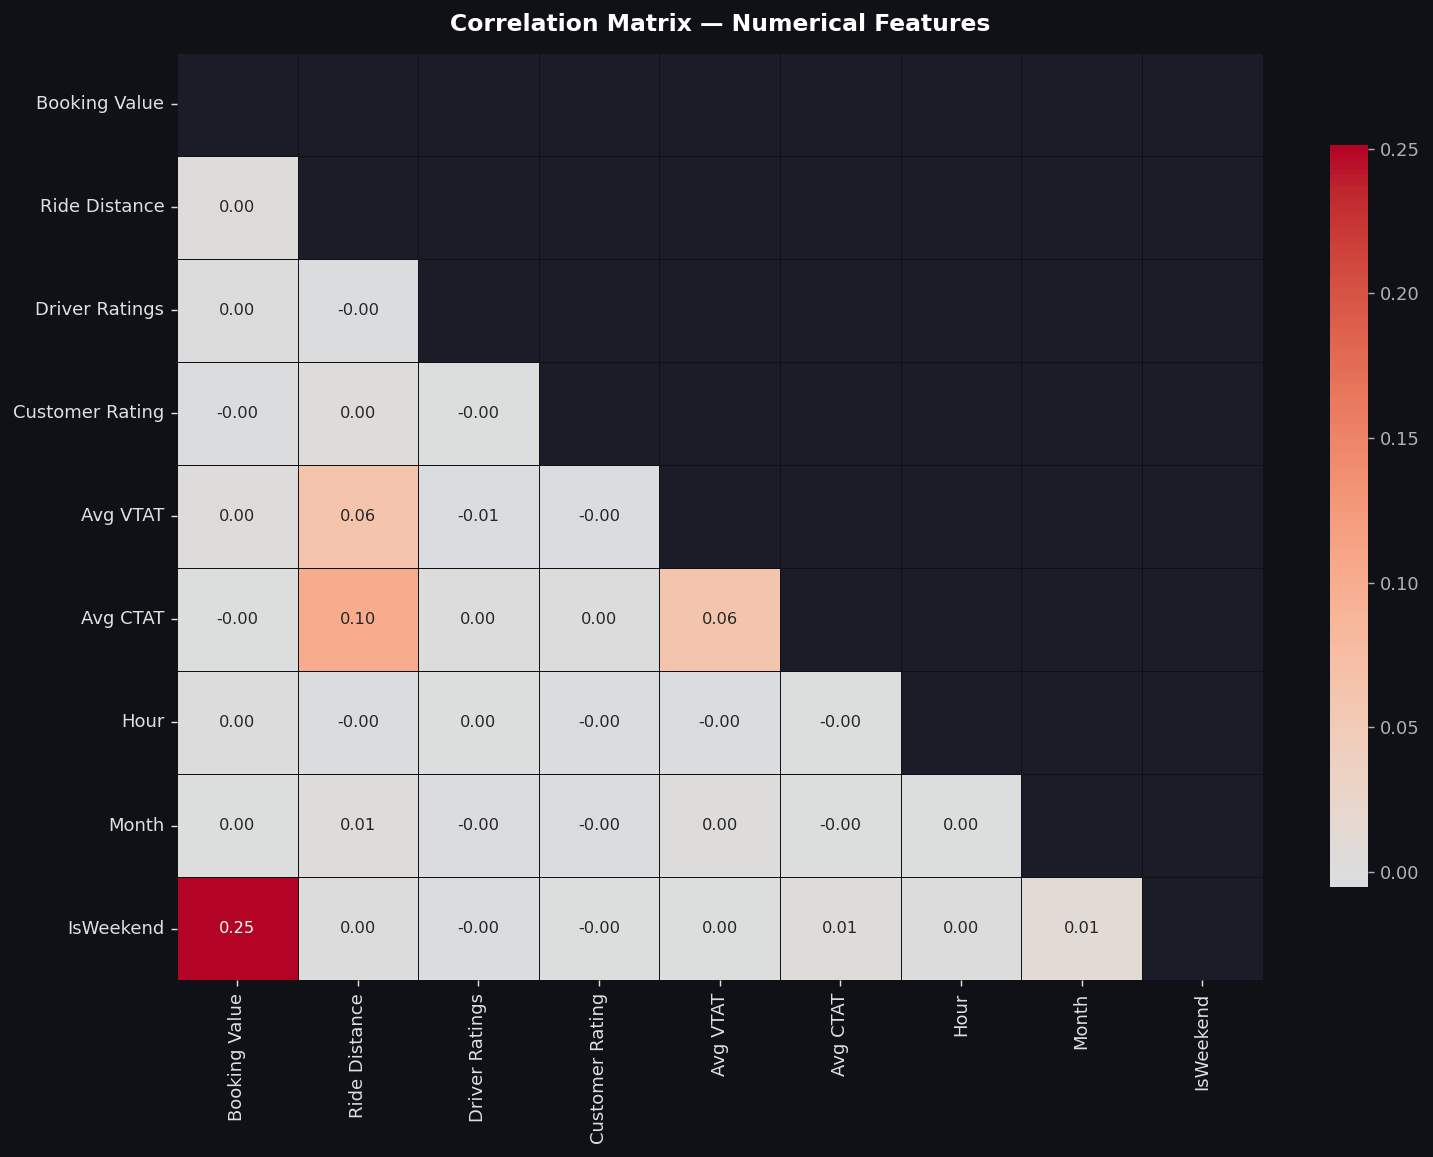

In [16]:
num_cols = ["Booking Value","Ride Distance","Driver Ratings","Customer Rating",
            "Avg VTAT","Avg CTAT","Hour","Month","IsWeekend"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9), facecolor="#0f1117")
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, annot=True,
            fmt=".2f", ax=ax, linewidths=0.5, linecolor="#0f1117",
            annot_kws={"size":9}, cbar_kws={"shrink":0.8})
ax.set_title("Correlation Matrix — Numerical Features",
             fontsize=13, fontweight="bold", color="#ffffff", pad=12)
ax.tick_params(colors="#e0e0e0")
fig.tight_layout(); plt.show()

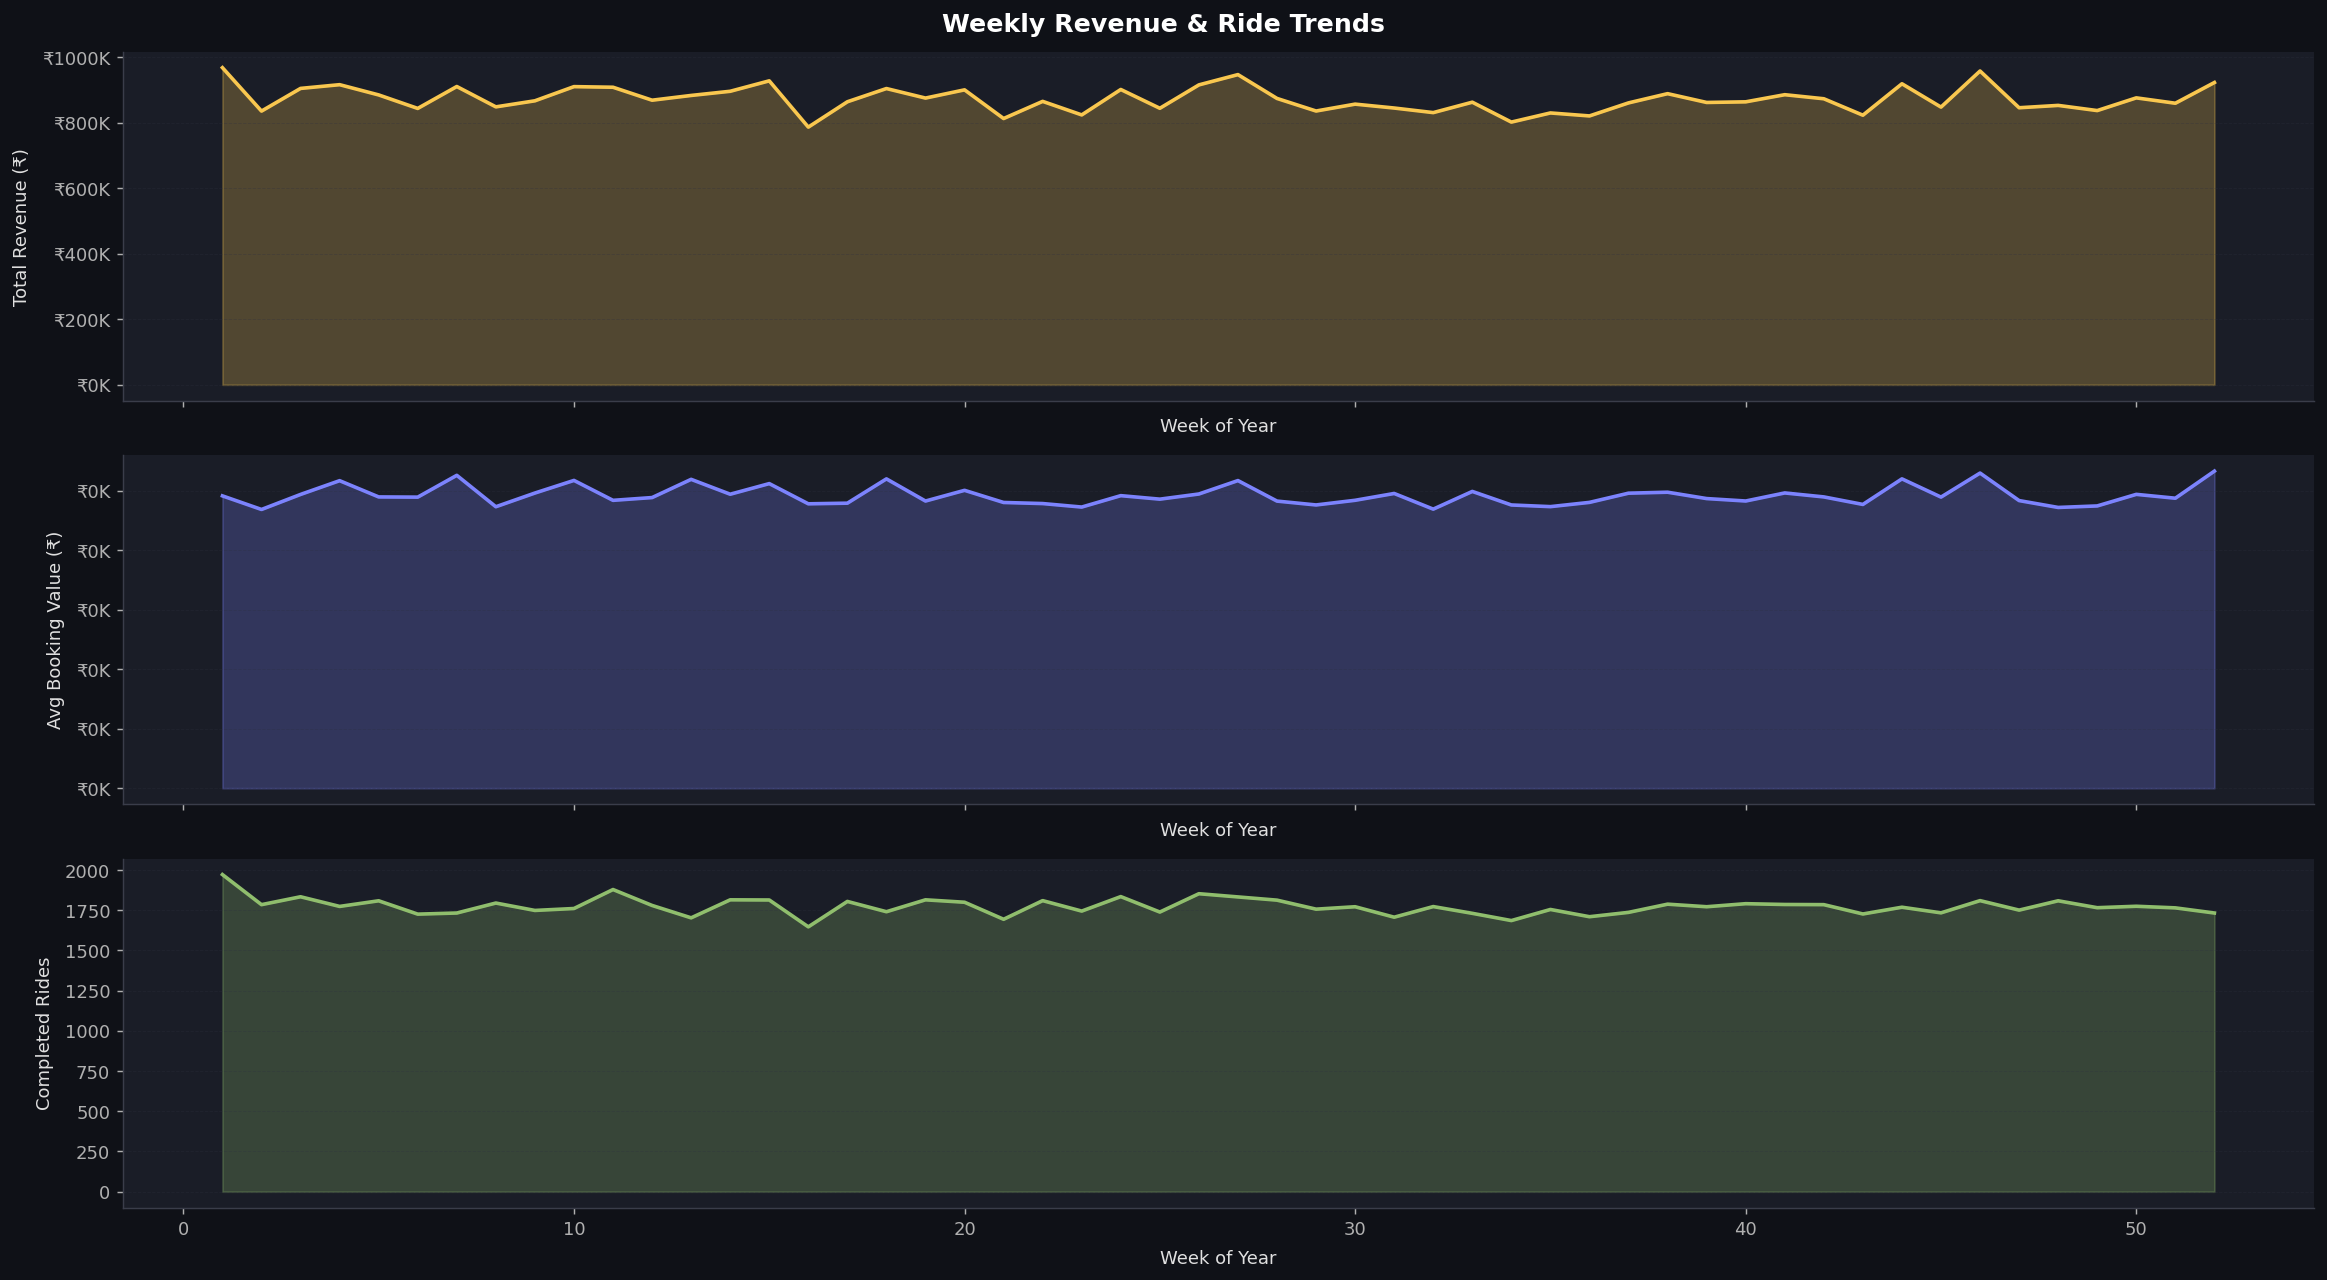

Peak revenue week : Week 1  (₹968,511)


In [17]:
comp = df[df["Booking Status"]=="Completed"].copy()
weekly_rev = comp.groupby("WeekOfYear")["Booking Value"].agg(["sum","mean","count"])

fig, axes = plt.subplots(3, 1, figsize=(18, 10), facecolor="#0f1117", sharex=True)
fig.suptitle("Weekly Revenue & Ride Trends", fontsize=14, fontweight="bold", color="#ffffff")

for ax, col, label, color in zip(axes,
    ["sum","mean","count"],
    ["Total Revenue (₹)","Avg Booking Value (₹)","Completed Rides"],
    [ACCENT2, ACCENT, SUCCESS]):
    ax.fill_between(weekly_rev.index, weekly_rev[col], alpha=0.25, color=color)
    ax.plot(weekly_rev.index, weekly_rev[col], color=color, linewidth=2)
    style_ax(ax, "", "Week of Year", label)
    if "Revenue" in label or "Value" in label:
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"₹{x/1000:.0f}K"))
fig.tight_layout(); plt.show()

print(f"Peak revenue week : Week {weekly_rev['sum'].idxmax()}  (₹{weekly_rev['sum'].max():,.0f})")

In [18]:
num_df  = df[["Booking Value","Ride Distance","Driver Ratings","Customer Rating","Avg VTAT","Avg CTAT"]]
summary = num_df.describe().T
summary["skew"]     = num_df.skew()
summary["kurtosis"] = num_df.kurtosis()
display(summary.round(3))

print("\n=== OUTLIER COUNT (IQR Method) ===")
for col in ["Booking Value","Ride Distance","Driver Ratings","Customer Rating"]:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)).sum()
    print(f"  {col:<25}: {outliers:>5} outliers  ({outliers/df[col].notna().sum()*100:.2f}%)")

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Booking Value,101175.0,491.997,331.727,50.0,234.00,414.00,689.00,1371.5,0.943,0.259
Ride Distance,101175.0,24.641,14.002,1.0,12.46,23.72,36.82,50.0,0.128,-1.213
Driver Ratings,92248.0,4.231,0.437,3.0,4.10,4.30,4.60,5.0,-0.656,0.282
Customer Rating,92248.0,4.404,0.438,3.0,4.20,4.50,4.80,5.0,-0.885,0.647
Avg VTAT,148767.0,8.435,3.634,2.0,5.60,8.20,11.00,19.1,0.320,-0.457
Avg CTAT,111576.0,29.118,8.477,10.0,22.40,28.80,35.90,45.0,0.060,-0.931



=== OUTLIER COUNT (IQR Method) ===
  Booking Value            :     0 outliers  (0.00%)
  Ride Distance            :     0 outliers  (0.00%)
  Driver Ratings           :  5162 outliers  (5.60%)
  Customer Rating          :  3237 outliers  (3.51%)
